In [2]:
from gc import DEBUG_LEAK

import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as scp
import uproot
import matplotlib
#from astropy.io.misc.asdf.tags.fits.fits import FitsType
from numba.cuda.libdevice import cbrtf
from pyvista.examples.cells import Pixel
from simpleparse.stt.TextTools import alpha
from sympy import false

font = {'weight' : 'bold',
        'size'   : 15}

matplotlib.rc('font', **font)
### Opticks Nexus Analysis

import h5py
from pandas import read_hdf
import seaborn as sns
import scipy.special as misc
from scipy.special import loggamma

isSafeFiles=False
SavePath="/home/argon/Projects/Ilker/CRAB_Diffusion/OpticksPaperImages/Needle"

In [3]:
import scipy.special as misc
from scipy.special import loggamma

def factorial(x):
    return np.math.factorial(np.uint64(x))

def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 

def Gauss1DSkew(x,Ampl,mean,sigma,a):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma+a*(x-mean))**2)) 

def Poisson1D(x,gamma):
    #vfactorial=np.vectorize(factorial)
    return (gamma**x)*np.exp(-gamma)/(misc.factorial(x))

## https://stackoverflow.com/questions/53308919/overflow-error-in-poisson-distribution-implementation
## Solves overflow issue
def log_Likelihood(x,gamma):
    return (np.log(gamma)*x - loggamma(x+1)-gamma)
    #return (np.log(gamma)*x - np.log(1/(misc.factorial(x)))-gamma)

def exp(x,A1,t1,A2,t2):
    return A1*np.exp(-x/t1)+A2*np.exp(-x/t2)

In [4]:
wavelength=lambda E:1239.8/E # ev to nm 
def GetInfo(filePath):
    All={}
    subVal={}
    subsubVal={}
    f=h5py.File(filePath,"r")
    
    for folder in f:
        subVal={}
        for table in f[folder]:
            subsubVal={}
            for field in f[folder][table].dtype.fields.keys():
                subsubVal[field]=f[folder][table][field]
            subVal[table]=subsubVal
        All[folder]=subVal
    f.close()    
    return All

In [5]:
#vv=GetInfo("/home/argon/Projects/Ilker/NewNexus/test.h5")
vv=GetInfo("/home/argon/Projects/Ilker/NewNexus/output/Opticks_Hit_Comparison/ComsolTest.h5")

In [6]:
print(vv)

{'MC': {'GEANT4_Optical_Hits': {'event_id': array([ 0,  0,  0, ..., 99, 99, 99]), 'name': array([b'PMTWindow', b'PMTWindow', b'PMTWindow', ..., b'camWindow',
       b'PMTWindow', b'PMTWindow'], dtype='|S100'), 'hit_id': array([    0,     1,     2, ..., 13327, 13328, 13329], dtype=int32), 'x': array([-8.874807 , -5.6062407, -1.9041333, ...,  3.1308825, -0.2940591,
        3.7438745], dtype=float32), 'y': array([ 1.377789 ,  4.9209266,  3.890212 , ..., -1.3048398, -0.3929403,
        2.556262 ], dtype=float32), 'z': array([-248.85, -248.85, -248.85, ...,  302.15, -248.85, -248.85],
      dtype=float32), 'time': array([ 61537.527,  48173.312,  55714.05 , ..., 109607.36 ,  98423.97 ,
       108864.6  ], dtype=float32), 'wavelength': array([168.38582, 177.11873, 174.91763, ..., 170.04976, 170.8478 ,
       179.53001], dtype=float32), 'polx': array([ 0.5776096 , -0.19543748, -0.3126456 , ..., -0.35649633,
       -0.64381635, -0.5757009 ], dtype=float32), 'poly': array([-0.79599106,  0.486570

In [7]:
if("DEBUG" in vv):
    DEBUG=vv["DEBUG"]
MC={}
if("MC" in MC):    
    MC=vv["MC"]
G4={}
if ("particles" in MC):
    G4=MC["particles"]
    Mask=G4["particle_name"]==b'opticalphoton'
    
InitialPhotonInfo={}
if ("Timing" in MC):
    InitialPhotonInfo=MC["Timing"]    

In [8]:
def FitHist1D(hist,ax,label,clr,ap):
    try:
        initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]),0.5)
        fit=scp.curve_fit(Gauss1DSkew,hist[1][:-1],hist[0],p0=initials)
        String_=label+r', $\bar{X}$'+f"={round(fit[0][1],2)}," + r'$\sigma$' +f"= {abs(round(fit[0][2],2))}"
        #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
        ax.plot(hist[1][:-1],Gauss1DSkew(hist[1][:-1],*fit[0]),label=String_,color=clr,alpha=ap,linewidth=3)
        print(*fit[0])
    except(RuntimeError):
        print("There was an error in fitting ")
    

def FitExp(hist,ax,label,clr,ap,fitType=["Hist",0]):
    try:
        if(fitType[0]=="Hist"):
            initials=(np.max(hist[0]),4.5,np.max(hist[0])/2,100)
            fit=scp.curve_fit(exp,hist[1][:-1],hist[0],p0=initials)
            String_=label+f",t1={abs(round(fit[0][1],2))},t2={abs(round(fit[0][3],2))}"
            #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
            ax.plot(hist[1][:-1],exp(hist[1][:-1],*fit[0]),label=String_,color=clr,alpha=ap,linewidth=3)
        else:
            initials=(np.max(hist),4.5,np.max(hist)/2,100)
            x=np.sort(hist)
            y=exp(x,*initials)
            fit=scp.curve_fit(exp,x,y,p0=initials)
            String_=label+f",t1={abs(round(fit[0][1],2))},t2={abs(round(fit[0][3],2))}"
            #ax.text(np.min(data),fit[0][0],s=String_,color=clr)
            
            ax.plot(x,exp(x,fit[0][0]*fitType[1],fit[0][1],fit[0][2]*fitType[1],fit[0][3]),label=String_,color=clr,alpha=ap,linewidth=3)
    except(RuntimeError):
        print("There was an error in fitting ")
    

In [9]:
OpticksHits={}
G4Hits={}
if("Opticks_Hits" in vv["MC"]):
    OpticksHits=vv['MC']['Opticks_Hits']

if("GEANT4_Optical_Hits" in vv["MC"]):
    G4Hits=vv['MC']['GEANT4_Optical_Hits']    

In [10]:
print(OpticksHits)
print(G4Hits)

{'event_id': array([ 0,  0,  0, ..., 99, 99, 99]), 'hit_id': array([     409,      803,     1801, ..., 11203343, 11204555, 11204556],
      dtype=int32), 'x': array([-3.653943 , -3.263494 , -1.4955788, ...,  5.3826423, -1.6803858,
        9.88674  ], dtype=float32), 'y': array([-2.1353278,  5.8816457,  5.543601 , ...,  8.406005 , -0.4851118,
        6.2449484], dtype=float32), 'z': array([-248.85, -248.85,  302.15, ..., -248.85, -248.85, -248.85],
      dtype=float32), 'time': array([46529.02 , 44162.188, 45089.145, ..., 97733.78 , 96699.08 ,
       96391.29 ], dtype=float32), 'wavelength': array([169.47334, 167.45547, 179.34229, ..., 167.28905, 165.39586,
       166.46446], dtype=float32), 'boundary': array([30, 30, 28, ..., 30, 30, 30], dtype=uint32), 'polx': array([ 0.881149  ,  0.9980477 , -0.90746343, ..., -0.6866609 ,
       -0.850567  , -0.8896752 ], dtype=float32), 'poly': array([ 0.47280443,  0.00718305, -0.41863593, ...,  0.7230162 ,
        0.5046931 ,  0.40805158], dtype=fl

In [11]:
#WavelengthsOpticks=np.concatenate((Opticks["wavelength"],OpticksHits["wavelength"]))
#WavelengthsG4=np.concatenate((wavelength(G4["kin_energy"][Mask]*1e6),G4Hits["wavelength"]))
#wMax=np.max(np.array([np.max(WavelengthsG4),np.max(WavelengthsOpticks)]))
#wMin=np.min(np.array([np.min(WavelengthsG4),np.min(WavelengthsOpticks)]))
if("DEBUG" in vv):
    wMax=np.max(np.array([np.max(wavelength(G4["kin_energy"][Mask]*1e6)),np.max(Opticks["wavelength"])]))
    wMin=np.min(np.array([np.min(wavelength(G4["kin_energy"][Mask]*1e6)),np.min(Opticks["wavelength"])]))
    
    bins_=np.linspace(wMin,wMax,150)
    
    plt.figure(figsize=(10,10),dpi=300)
    plt.title("Wavelength Comparison")
    
    h1=plt.hist(Opticks["wavelength"],bins=bins_,alpha=0.3,label="Opticks",color="red",histtype="step",fill=True)
    #h1=plt.hist(WavelengthsOpticks,bins=bins_,alpha=1,label="Opticks",color="red",alpha=0.3,histtype="step",fill=True)
    FitHist1D(h1,plt,"Fit","red",0.3)
    
    
    h2=plt.hist(wavelength(G4["kin_energy"][Mask]*1e6),bins=bins_,alpha=0.3,label="G4",histtype="step",color="green",fill=True)
    #h2=plt.hist(WavelengthsG4,bins=bins_,alpha=0.5,label="G4",histtype="step",color="green",alpha=0.4,fill=True)
    FitHist1D(h2,plt,"Fit","green",0.3)
    plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
    plt.xlabel("wavelength (nm)")
    plt.legend()
    if(isSafeFiles):
        plt.savefig(f"{SavePath}/S1_Wavelength.png")
    del h1,h2

In [12]:
if("DEBUG" in vv):
    Mask=G4["particle_name"]==b'opticalphoton'
    if(OpticksHits):
        OpticksPhotonTime=OpticksHits["time"]
    G4PhotonTimeInitial=G4["initial_t"][Mask]
    G4PhotonTimeFinal=G4["final_t"][Mask]

In [13]:
if("DEBUG" in vv):
    wMax=np.max(np.array([np.max(G4PhotonTimeFinal),np.max(OpticksPhotonTime)]))
    wMin=np.min(np.array([np.min(G4PhotonTimeFinal),np.min(OpticksPhotonTime)]))
    bins_=np.linspace(wMin,wMax,200)
    
    plt.figure(figsize=(8,8),dpi=300)
    plt.title("S1 Photons")
    #plt.hist(timeDifference,bins=bins_,label="G4")
    h1=plt.hist(OpticksPhotonTime,bins=bins_,label="Opticks",alpha=0.3,color="red",histtype="step",fill=True)
    FitExp(h1,plt,"Fit","red",0.3)
    h2=plt.hist(G4PhotonTimeFinal,bins=bins_,label="G4",alpha=0.3,color="green",histtype="step",fill=True)
    FitExp(h2,plt,"Fit","Green",0.3)
    #_=plt.hist(G4PhotonTimeInitial,bins=200,alpha=0.5,label="final",hatch="//")
    plt.legend()
    plt.xlabel("time(ns)")
    print(f"max {wMax} and min {wMin}")
    if(isSafeFiles):
        plt.savefig(f"{SavePath}/S1_Timing_Initial.png")
    del h1,h2

69580.5791102827 171.56888016068396 5.505137344232203 0.03327879737344895
70640.90803663128 171.5529068035786 -5.484726713513814 -0.03284491371642288


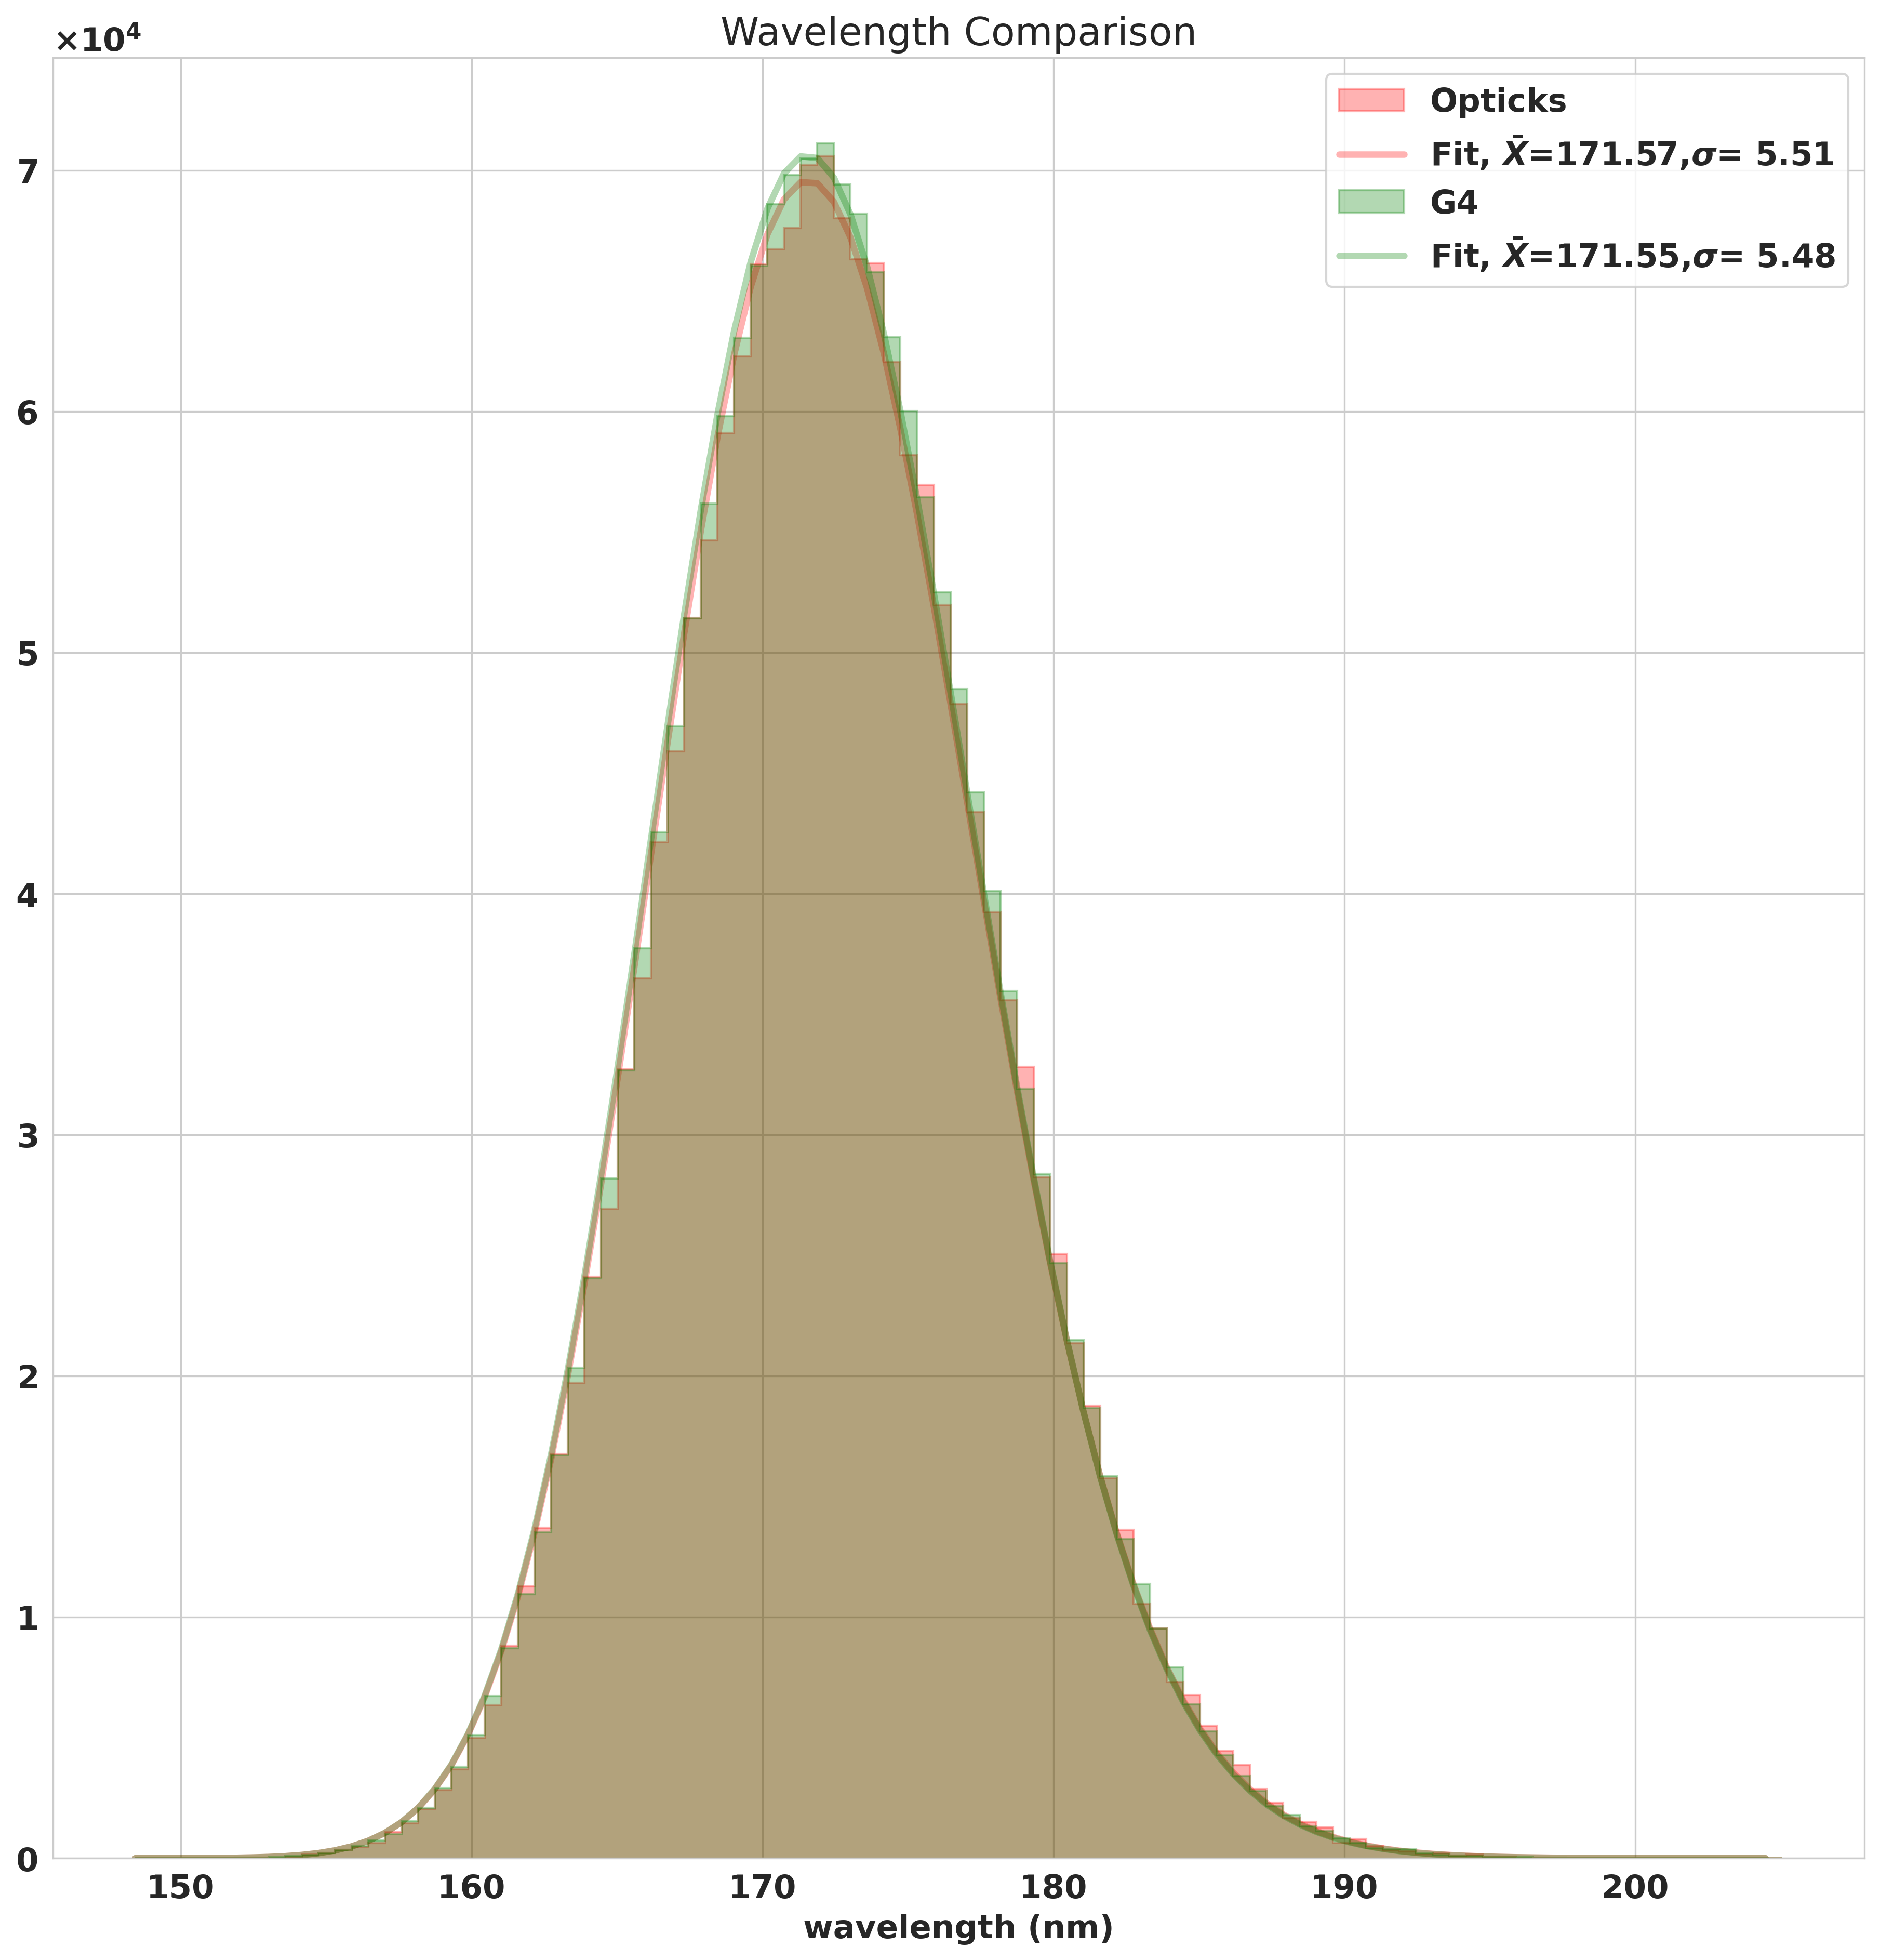

In [14]:
if(G4Hits):
    wMax=np.max(np.array([np.max(G4Hits["wavelength"]),np.max(OpticksHits["wavelength"])]))
    wMin=np.min(np.array([np.min(G4Hits["wavelength"]),np.min(OpticksHits["wavelength"])]))
    
    plt.figure(figsize=(15,15),dpi=300)
    bins_=np.linspace(wMin,wMax,100)
    plt.title("Wavelength Comparison")
    h1=plt.hist(OpticksHits["wavelength"],bins=bins_,alpha=0.3,label="Opticks",color="red",histtype="step",fill=True)
    FitHist1D(h1,plt,"Fit","red",0.3)
    #FitHist1D(OpticksHits["wavelength"],plt,"Fit","red",0.3,FitsType="data")
    
    h2=plt.hist(G4Hits["wavelength"],bins=bins_,alpha=0.3,label="G4",color="green",histtype="step",fill=True)
    FitHist1D(h2,plt,"Fit","green",0.3)
    #FitHist1D(G4Hits["wavelength"],plt,"Fit","green",0.3,FitsType="data")
    
    plt.xlabel("wavelength (nm)")
    plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
    
    plt.legend()
    if(isSafeFiles):
        plt.savefig(f"{SavePath}/S1_Hit_Wavelength.png")
    del h1,h2


There was an error in fitting 
69580.5791102827 171.56888016068396 5.505137344232203 0.03327879737344895


/home/argon/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


70640.90803663128 171.5529068035786 -5.484726713513814 -0.03284491371642288


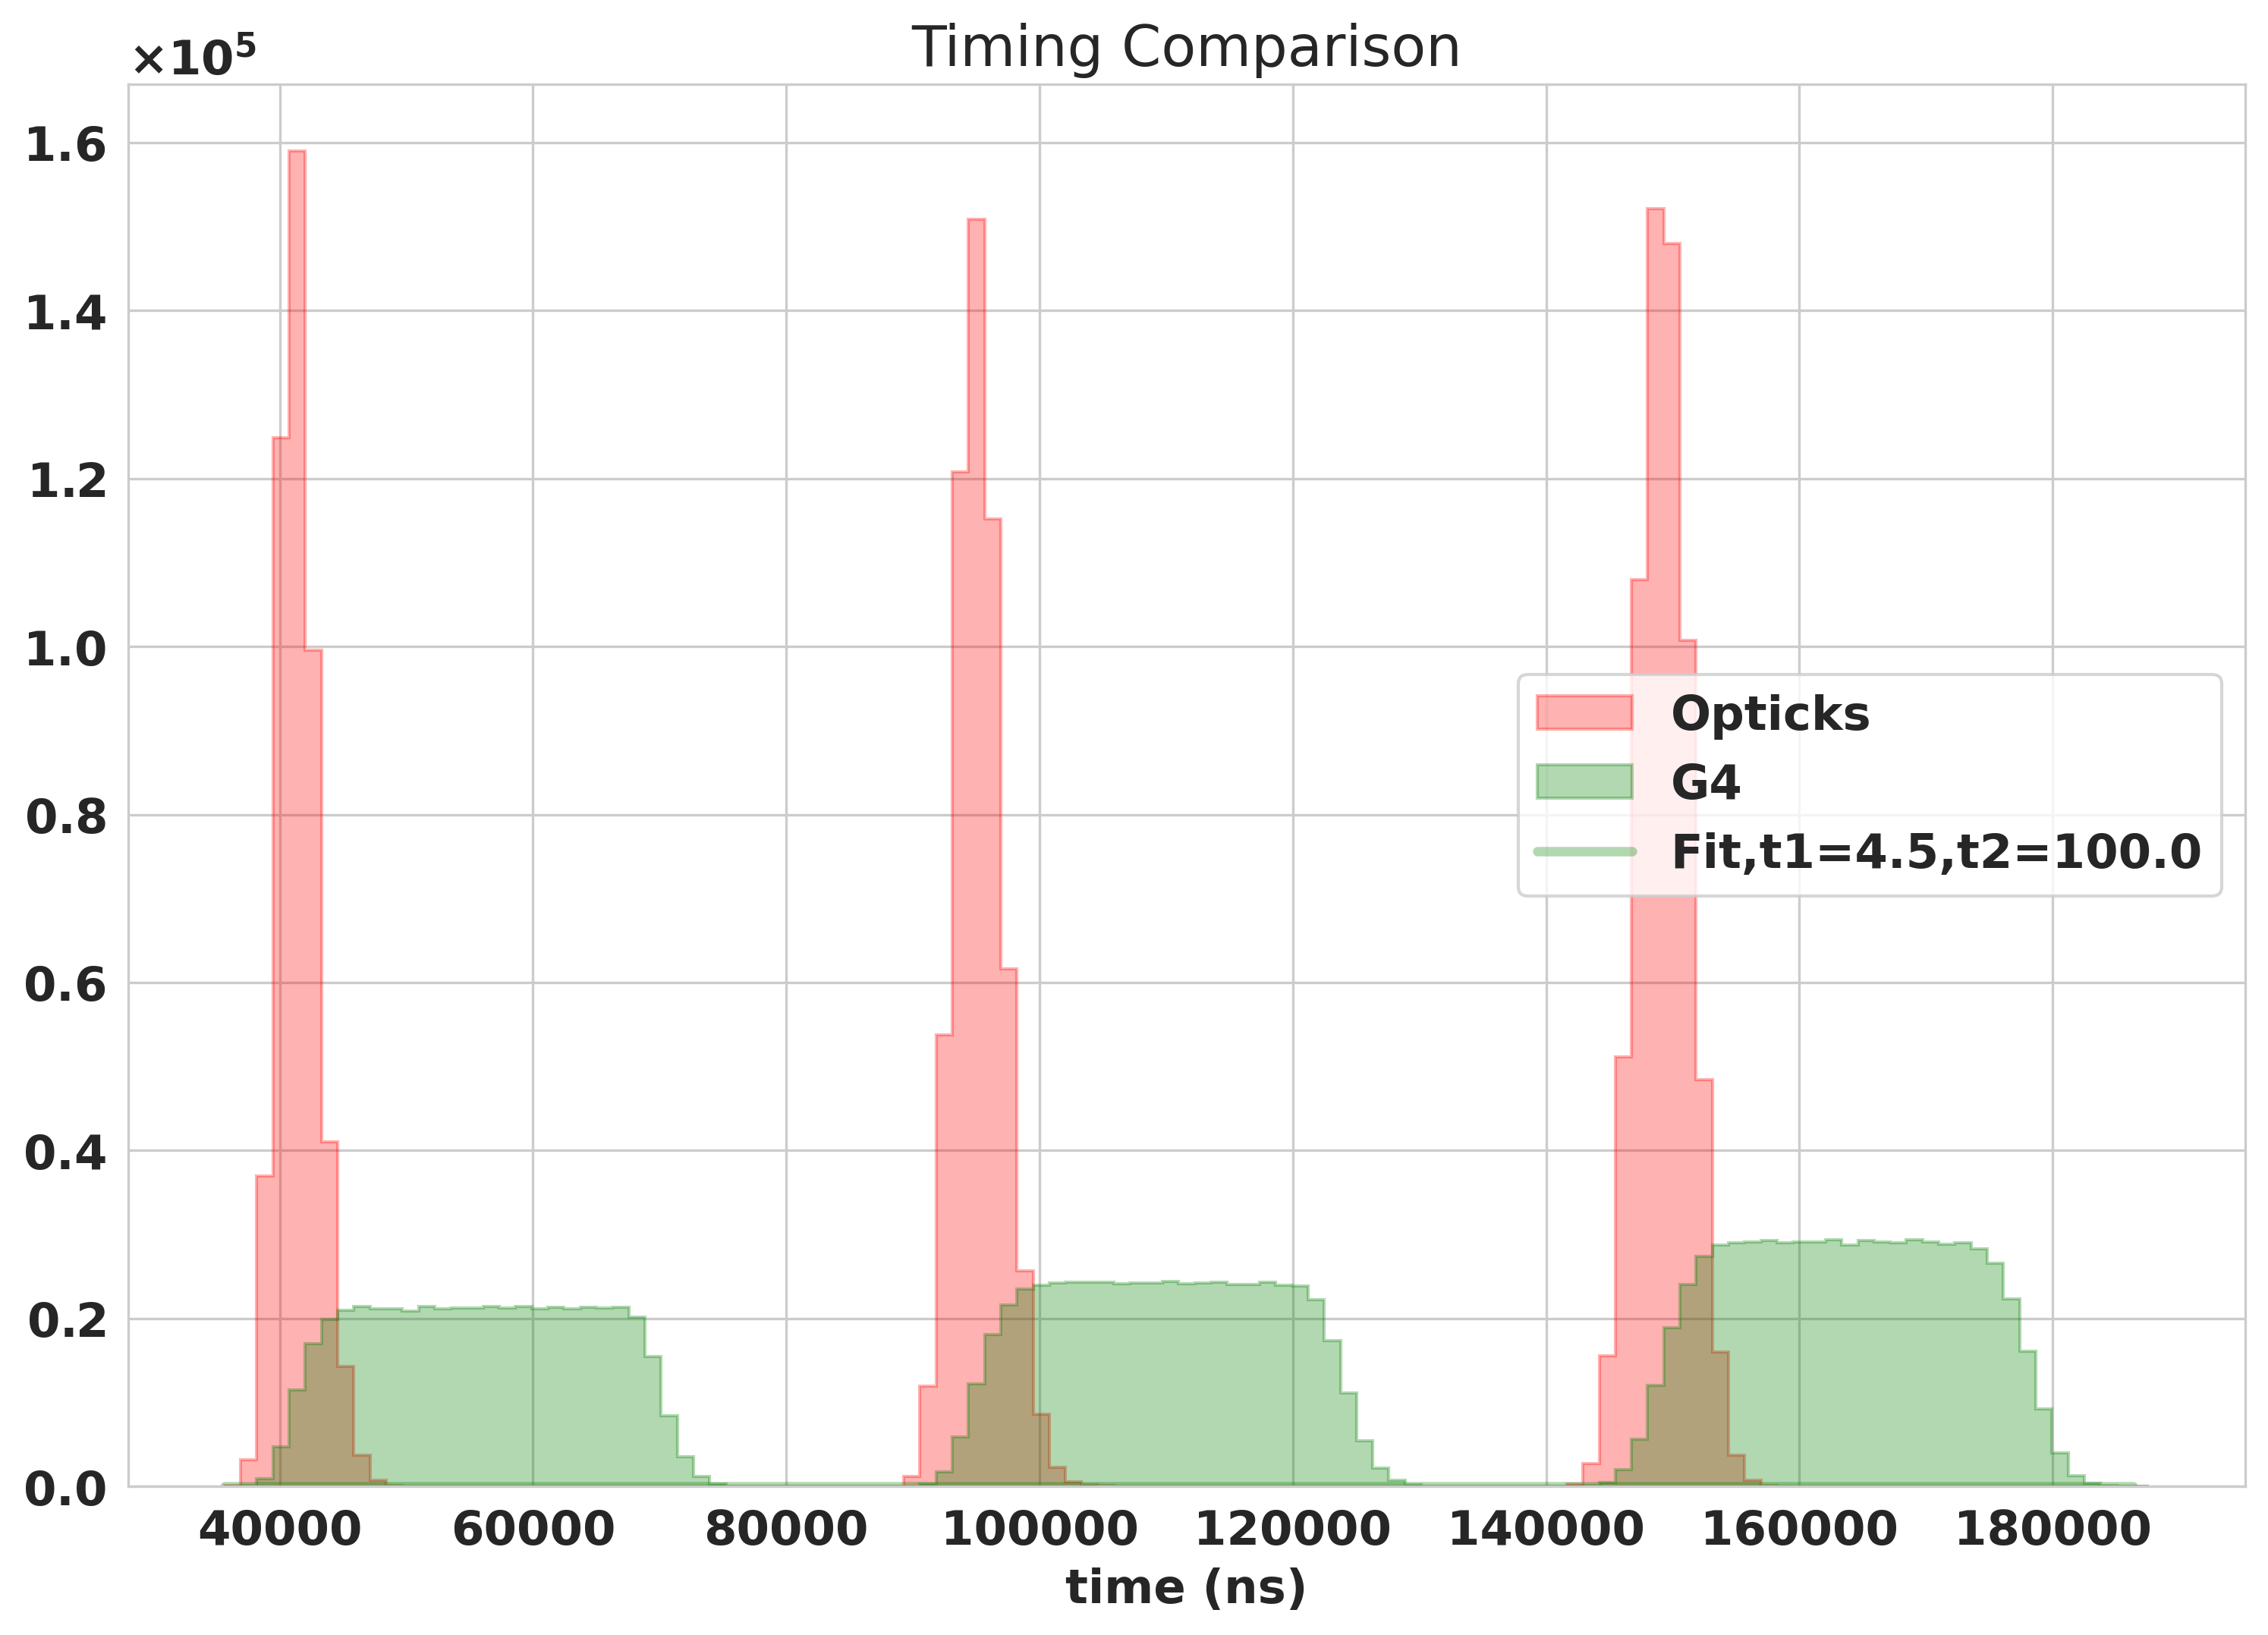

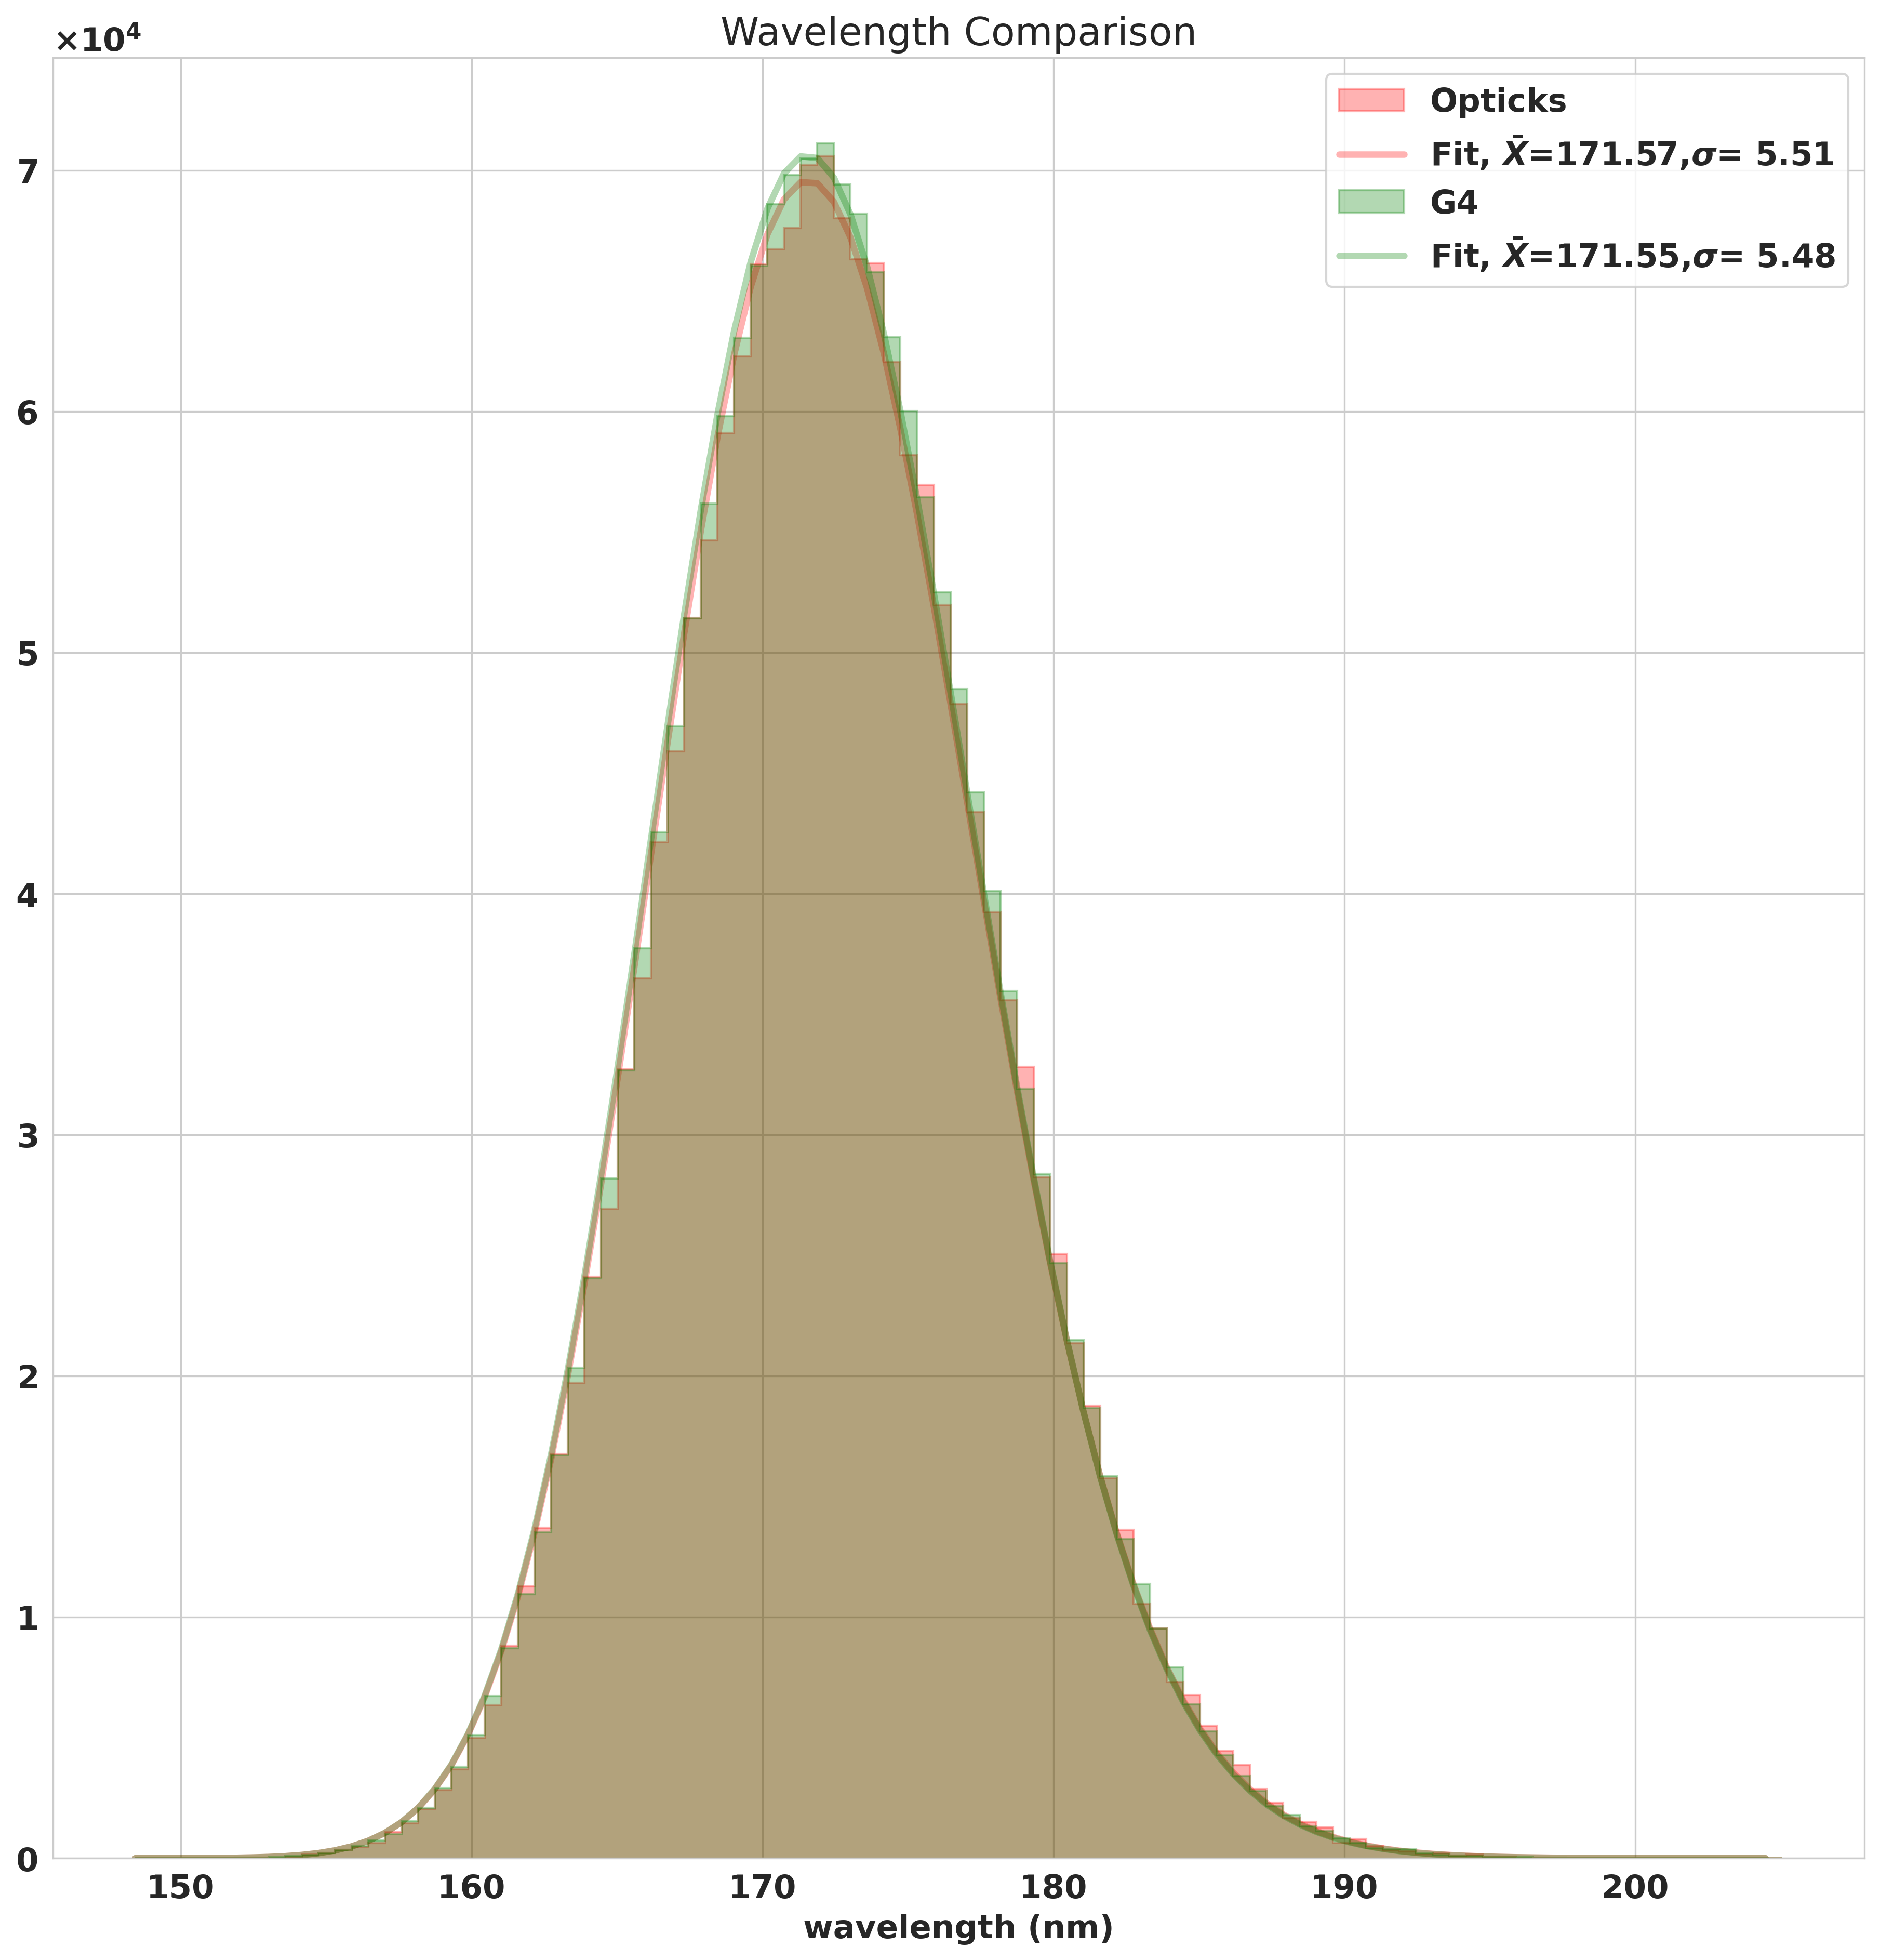

In [15]:
G4HitTime=0
OpticksHitTime=0
if(G4Hits):
    G4HitTime=G4Hits["time"]
if(OpticksHits):
    OpticksHitTime=OpticksHits["time"]

wMax=np.max(np.array([np.max(G4HitTime),np.max(OpticksHitTime)]))
wMin=np.min(np.array([np.min(G4HitTime),np.min(OpticksHitTime)]))

plt.figure(figsize=(12,8),dpi=300)
bins_=np.linspace(wMin,wMax,120)
plt.title("Timing Comparison")

h1=plt.hist(OpticksHitTime,bins=bins_,alpha=0.3,label="Opticks",color="red",histtype="step",fill=True)
FitExp(h1,plt,"Fit","red",0.3)
#FitExp(OpticksHitTime,plt,"Fit","red",0.3,fitType=["",np.mean(h1[0])])

h2=plt.hist(G4HitTime,bins=bins_,alpha=0.3,label="G4",color="green",histtype="step",fill=True)
FitExp(h2,plt,"Fit","Green",0.3)
#FitExp(G4HitTime,plt,"Fit","Green",0.3,fitType=["",np.mean(h2[0])])
plt.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
#plt.xlim(80000,wMax)
plt.xlabel("time (ns)")
plt.legend()
wMax = np.max(np.array([np.max(G4Hits["wavelength"]), np.max(OpticksHits["wavelength"])]))
wMin = np.min(np.array([np.min(G4Hits["wavelength"]), np.min(OpticksHits["wavelength"])]))

plt.figure(figsize=(15, 15), dpi=300)
bins_ = np.linspace(wMin, wMax, 100)
plt.title("Wavelength Comparison")
h1 = plt.hist(OpticksHits["wavelength"], bins=bins_, alpha=0.3, label="Opticks", color="red", histtype="step",
              fill=True)
FitHist1D(h1, plt, "Fit", "red", 0.3)
h2 = plt.hist(G4Hits["wavelength"], bins=bins_, alpha=0.3, label="G4", color="green", histtype="step", fill=True)
FitHist1D(h2, plt, "Fit", "green", 0.3)

plt.xlabel("wavelength (nm)")
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

plt.legend()
if (isSafeFiles):
    plt.savefig(f"{SavePath}/S1_Hit_Timing.png")

del h1,h2

In [16]:
## Opticks
#OpticksPMTMask=OpticksHits['boundary']==31 ##PMT
#OpticksCamMask=OpticksHits['boundary']==30 ##Camera
## Opticks
#OpticksPMTMask=OpticksHits['boundary']==31 ##PMT
#OpticksCamMask=OpticksHits['boundary']==30 ##Camera
## Geant4
OpticsS1PMTMask=np.array([])
OpticksS1CamMask=np.array([])
OpticsS2PMTMask=np.array([])
OpticksS2CamMask=np.array([])
bnd=[]
if(G4Hits):
    Geant4PMTMask=G4Hits['name']==b'PMTWindow' ##PMT
    Geant4CamMask=G4Hits['name']==b'camWindow' ##Camera
if(OpticksHits):
    OpticksPMTMask=(OpticksHits['z']<100)    ##PMT
    OpticksCamMask=(OpticksHits['z']>200)  
    ##Camera
    bnd=[np.unique(OpticksHits['boundary'][OpticksPMTMask]),np.unique(OpticksHits['boundary'][OpticksCamMask])]
    print(bnd)
    if(len(bnd[0])>1 or len(bnd[1])>1):
        print("Boundary issue ")
        bnd=[bnd[0],bnd[1]]



[array([30], dtype=uint32), array([28], dtype=uint32)]


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([-1.26999846e+01, -1.26503779e+01, -1.26007713e+01, -1.25511647e+01,
        -1.25015581e+01, -1.24519515e+01, -1.24023449e+01, -1.23527383e+01,
        -1.23031316e+01, -1.22535250e+01, -1.22039184e+01, -1.21543118e+01,
        -1.21047052e+01, -1.20550986e+01, -1.20054920e+01, -1.19558853e+01,
        -1.19062787e+01, -1.18566721e+01, -1.18070655e+01, -1.17574589e+01,
        -1.17078523e+01, -1.16582457e+01, -1.16086390e+01, -1.15590324e+01,
        -1.15094258e+01, -1.14598192e+01, -1.14102126e+01, -1.13606060e+01,
        -1.13109994e+01, -1.12613927e+01, -1.12117861e+01, -1.11621795e+01,
        -1.11125729e+01, -1.10629663e+01, -1.10133597e+01, -1.09637531e+01,
        -1.09141465e+01, -1.08645398e+01, -1.08149332e+01, -1.07653

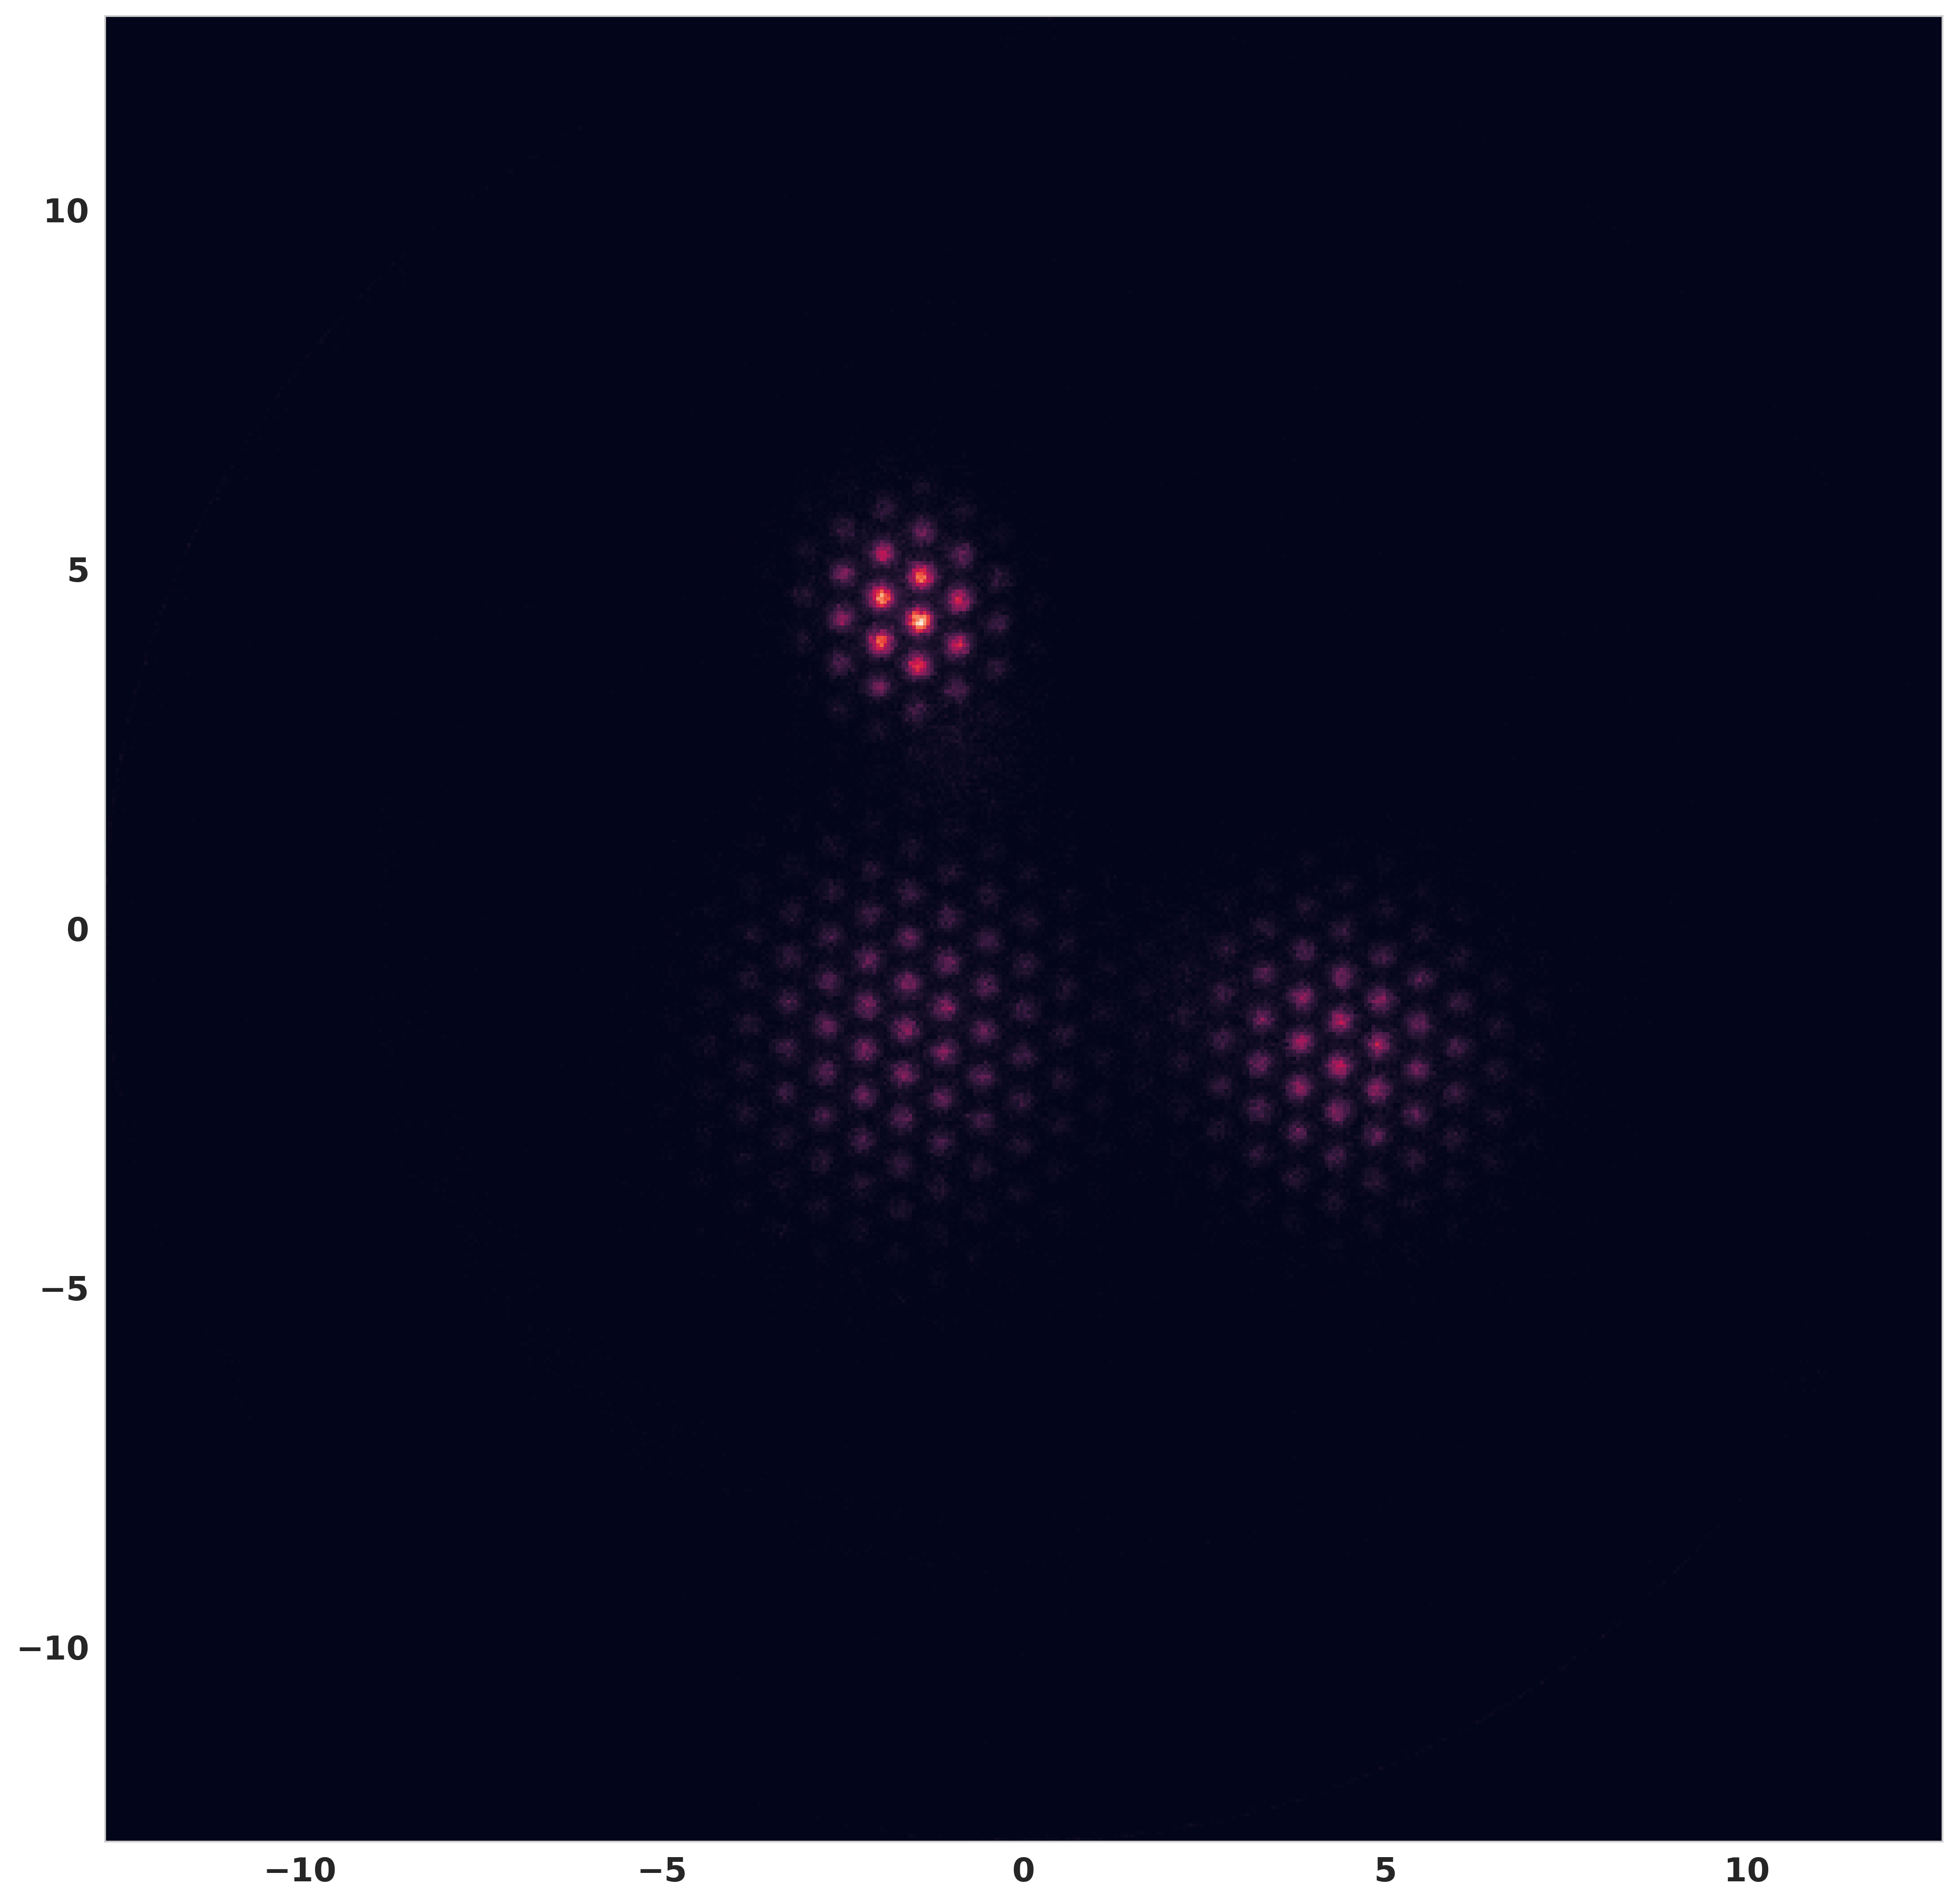

In [17]:
#plt.hist2d(G4Hits["x"][Geant4PMTMask], G4Hits["y"][Geant4PMTMask], bins=200)
plt.figure(figsize=(15, 15), dpi=300)
plt.hist2d(OpticksHits["x"][OpticksCamMask], OpticksHits["y"][OpticksCamMask], bins=512)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([-1.26999722e+01, -1.25730034e+01, -1.24460347e+01, -1.23190659e+01,
        -1.21920971e+01, -1.20651284e+01, -1.19381596e+01, -1.18111909e+01,
        -1.16842221e+01, -1.15572534e+01, -1.14302846e+01, -1.13033159e+01,
        -1.11763471e+01, -1.10493784e+01, -1.09224096e+01, -1.07954409e+01,
        -1.06684721e+01, -1.05415034e+01, -1.04145346e+01, -1.02875659e+01,
        -1.01605971e+01, -1.00336284e+01, -9.90665963e+00, -9.77969088e+00,
        -9.65272213e+00, -9.52575338e+00, -9.39878463e+00, -9.27181588e+00,
        -9.14484713e+00, -9.01787838e+00, -8.89090962e+00, -8.76394087e+00,
        -8.63697212e+00, -8.51000337e+00, -8.38303462e+00, -8.25606587e+00,
        -8.12909712e+00, -8.00212837e+00, -7.87515962e+00, -7.74819

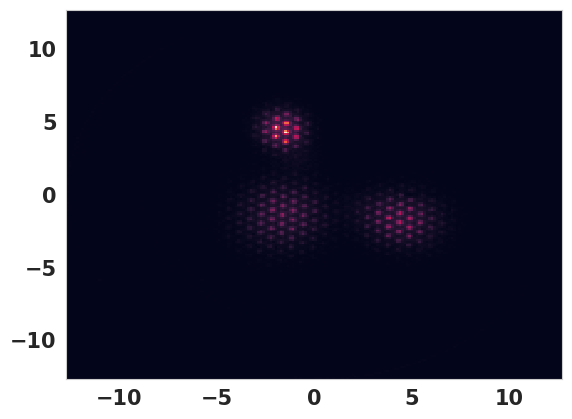

In [18]:
plt.hist2d(G4Hits["x"][Geant4CamMask],G4Hits["y"][Geant4CamMask],bins=200)

1478767


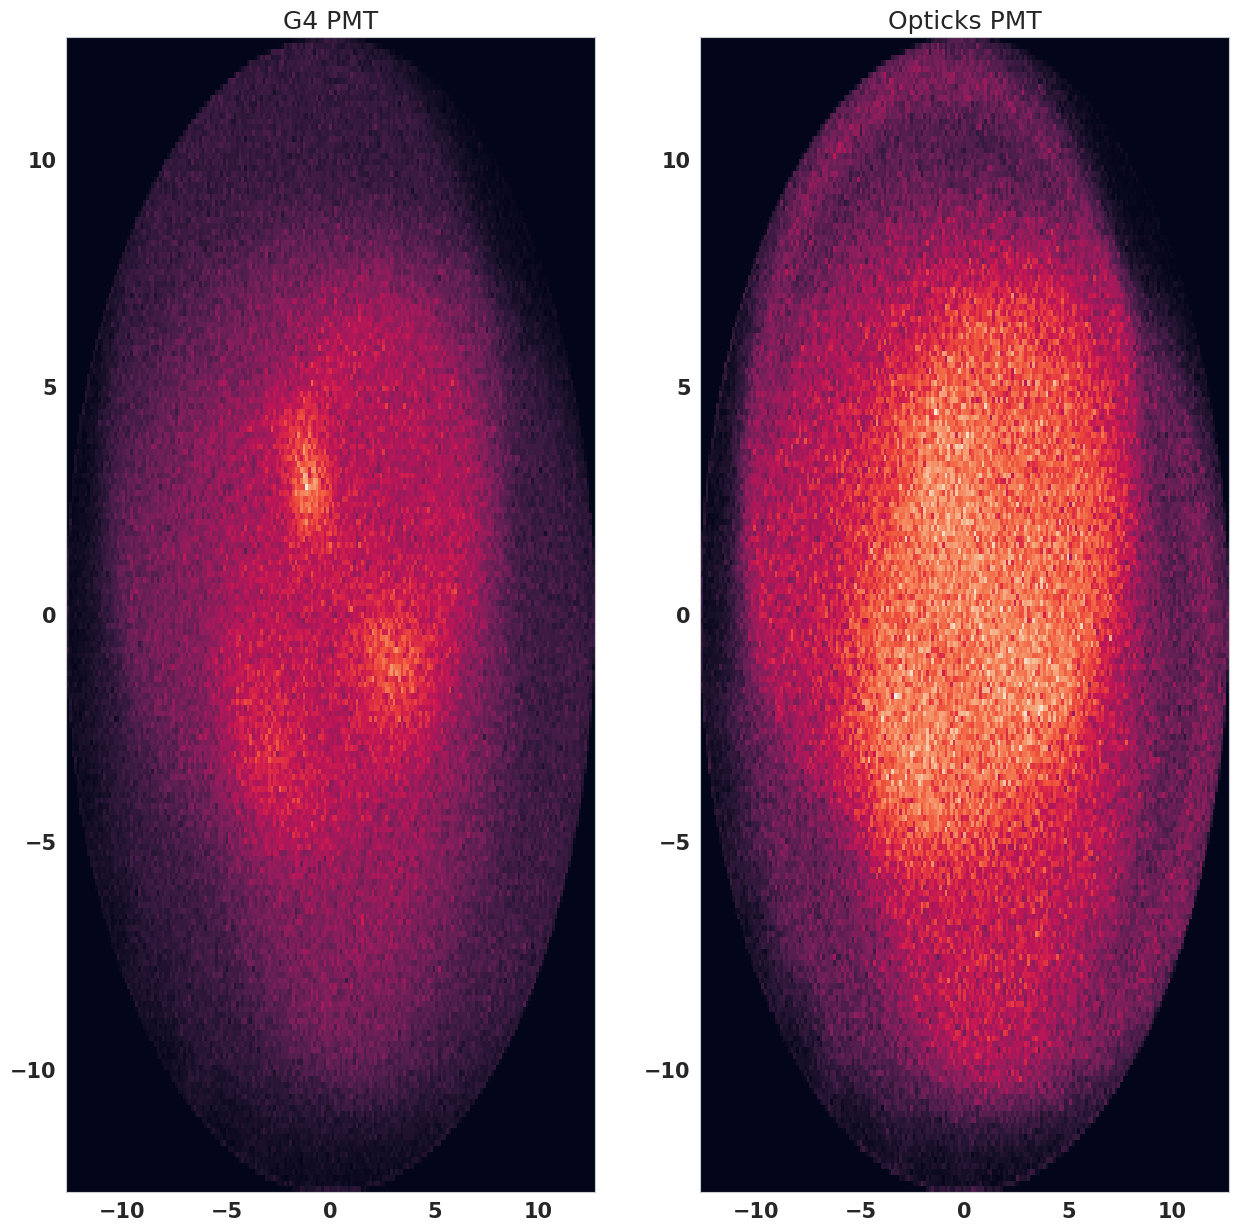

<Figure size 7500x7500 with 0 Axes>

In [19]:
fig,ax=plt.subplots(1,2)
fig.set_figheight(15)
fig.set_figwidth(15)
Binsize=200
G4X=G4Hits["x"][Geant4PMTMask]
G4Y=G4Hits["y"][Geant4PMTMask]
print(len(G4X))
OX=OpticksHits['x'][OpticksPMTMask]
OY=OpticksHits['y'][OpticksPMTMask]

maXX=np.max(np.array([np.max(G4X),np.max(OX)]))
miNX=np.min(np.array([np.min(G4X),np.min(OX)]))
lins1X=np.linspace(miNX,maXX,Binsize)

maXY=np.max(np.array([np.max(G4Y),np.max(OY)]))
miNY=np.min(np.array([np.min(G4Y),np.min(OY)]))
lins1Y=np.linspace(miNY,maXY,Binsize)
plt.figure(figsize=(25,25),dpi=300)
ax[0].set_title("G4 PMT")
ax[0].hist2d(G4X,G4Y,bins=[lins1X,lins1Y],label="G4")
ax[1].set_title("Opticks PMT")
ax[1].hist2d(OX,OY,bins=[lins1X,lins1Y],label="Opticks")

plt.show()

In [104]:
def PlotFit1D(xval,yval,ax,title,type="Gauss",bin=100,colors=["red","green"],labels=["Opticks","Geant4"],axislabels=["Frequency","Wavelength (nm)"]):
    wMax=np.max(np.array([np.max(xval),np.max(yval)]))
    wMin=np.min(np.array([np.min(xval),np.min(yval)]))
    
    bins_=np.linspace(wMin,wMax,bin)
    ax.set_title(title)
    h1=ax.hist(xval,bins=bins_,alpha=0.3,label=labels[0],color=colors[0],edgecolor=colors[0],histtype="step",fill=True)
    FitHist1D(h1,ax,"Fit",colors[0],0.5) if (type=="Gauss") else FitExp(h1,ax,"Fit",colors[0],0.5) 

    
    h2=ax.hist(yval,bins=bins_,alpha=0.3,label=labels[1],histtype="step",fill=True,color=colors[1],edgecolor=colors[1])
    FitHist1D(h2,ax,"Fit",colors[1],0.5) if (type=="Gauss") else FitExp(h2,ax,"Fit",colors[1],0.5) 
   
    ax.set_xlabel(axislabels[1])
    ax.set_ylabel(axislabels[0])
    ax.legend()
    ax.ticklabel_format(axis='y',style='sci',scilimits=(0,0),useMathText=True)
    del h1,h2

def CamResponse(val):
        x=val[0]
        y=val[1]
        theta=-np.pi/7
        costet=np.cos(theta)
        sintet=np.sin(theta)
        pixelsize=0.016

        XRotated=(x*costet-sintet*y)
        YRotated=-(x*sintet+costet*y)

        #XRotated=((XRotated)/(pixelsize*3.5))+260+10
        #YRotated=((YRotated)/(pixelsize*3.5)+230+40)
        XRotated=((XRotated)/(pixelsize*3.7))+260-20
        YRotated=((YRotated)/(pixelsize*3.7)+230+60)
        X=np.array(XRotated)
        Y=np.array(YRotated)
        Dict={"x":X,"y":Y}
        return Dict

def Plot2D_JointPlot(valO,ValG4,FileName,Title,Binsize=200,isPlottext=False,vnorm=None,isCameraView=False,labels=["x(mm)","y(mm)"]):
    maXX=0
    miNX=0
    maXY=0
    miNY=0
    lins1X=0
    lins1Y=0
    if(isCameraView):
        Op_dic=CamResponse(valO)
        valO[0]=Op_dic["x"]
        valO[1]=Op_dic["y"]
        
        G4_dic=CamResponse(ValG4)
     
        ValG4[0]=G4_dic["x"]
        ValG4[1]=G4_dic["y"]
        
        maXX=512
        miNX=0
        maXY=512
        miNY=0
        lins1X=np.arange(miNX,maXX,1)
        lins1Y=np.arange(miNY,maXY,1)
    else:
        maXX=np.max(np.array([np.max(ValG4[0]),np.max(valO[0])]))
        miNX=np.min(np.array([np.min(ValG4[0]),np.min(valO[0])]))
        maXY=np.max(np.array([np.max(ValG4[1]),np.max(valO[1])]))
        miNY=np.min(np.array([np.min(ValG4[1]),np.min(valO[1])]))
        lins1X=np.linspace(miNX,maXX,Binsize)
        lins1Y=np.linspace(miNY,maXY,Binsize)
    
    G4Dict={labels[0]:ValG4[0],labels[1]:ValG4[1]}
    OpticksDict={labels[0]:valO[0],labels[1]:valO[1]}
    plt.figure(figsize=(15,15),dpi=300)
    g=sns.jointplot(data=G4Dict,x=labels[0], y=labels[1], kind='hist',bins=[lins1X,lins1Y],marginal_kws={"bins":Binsize,"kde":True},cmap="viridis",color="green",height=10,cbar=True,cbar_kws={"use_gridspec":False, "location":"top","aspect":50,"fraction":0.016,"pad":0,"aspect":50});
    plt.hist2d(ValG4[0], ValG4[1], bins=[lins1X,lins1Y], cmap="viridis");
    if(isPlottext):
        x_mean = round(np.mean(ValG4[0]),2)
        x_std = round(np.std(ValG4[0]),2)
        g.ax_marg_x.axvspan(x_mean - x_std, x_mean + x_std, color='gray', alpha=0.35)

        y_mean = round(np.mean(ValG4[1]),2)
        y_std = round(np.std(ValG4[1]),2)
        g.ax_marg_y.axhspan(y_mean - y_std, y_mean + y_std, color='gray', alpha=0.35)
        g.refline(x=x_mean, y=y_mean, color='green', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        print(x_mean,x_std)
        labelX_str=r'$\bar{X}$' + f" = {str(x_mean)}, " + r'$\sigma_{X}$'+f" = {str(x_std)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(y_mean)}, \n " + r'$\sigma_{Y}$'+f" = {str(y_std)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(x_mean + 2*x_std, np.mean(Ydata), labelX_str, fontsize=12)
        ax_marg_y.text( np.mean(Xdata),y_mean + 2*y_std, labelY_str, fontsize=12)
        
    
    #g.plot_joint(sns.kdeplot, color="red", zorder=0, alpha=0.3,levels=6)
    #g.plot_marginals(sns.rugplot,  color="red", height=+.02, clip_on=False)
    plt.suptitle(Title[1],fontweight="bold",ha="left",size="medium")
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[1]}.png")
        
    g=sns.jointplot(data=OpticksDict,x=labels[0],y= labels[1] ,kind='hist',bins=[lins1X,lins1Y],cmap="viridis",marginal_kws={"bins":Binsize,"kde":True},color="red",height=10,cbar=True,cbar_kws={"use_gridspec":True,"fraction":0.016,"pad":0,"location":"top","aspect":50});

    #g.plot_joint(sns.kdeplot,  color="green",alpha=0.3, zorder=0, levels=6)
    #g.plot_marginals(sns.rugplot,  color="green", height=+.02, clip_on=False)

    if(vnorm!=None):
        plt.hist2d(valO[0], valO[1], bins=[lins1X,lins1Y], cmap="viridis",vmin=vnorm[0],vmax=vnorm[1])
    else:
        plt.hist2d(valO[0], valO[1], bins=[lins1X,lins1Y], cmap="viridis")
    
    if(isPlottext):
        x_mean = round(np.mean(valO[0]),2)
        x_std = round(np.std(valO[0]),2)
        g.ax_marg_x.axvspan(x_mean - x_std, x_mean + x_std, color='gray', alpha=0.35)
    
        y_mean = round(np.mean(valO[1]),2)
        y_std = round(np.std(valO[1]),2)
        g.ax_marg_y.axhspan(y_mean - y_std, y_mean + y_std, color='gray', alpha=0.35)
        g.refline(x=x_mean, y=y_mean, color='red', ls='--',alpha=0.3)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        print(x_mean,x_std)
        labelX_str=r'$\bar{X}$' + f" = {str(x_mean)}, "+ r'$\sigma_{X}$'+f" = {str(x_std)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(y_mean)}, \n " + r'$\sigma_{Y}$'+f" = {str(y_std)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(x_mean + 2*x_std, np.mean(Ydata), labelX_str, fontsize=12)
        ax_marg_y.text( np.mean(Xdata),y_mean + 2*y_std, labelY_str, fontsize=12)
    
    plt.suptitle(Title[0],fontweight="bold",ha="left",size="medium")
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[0]}.png")

<Figure size 4500x4500 with 0 Axes>

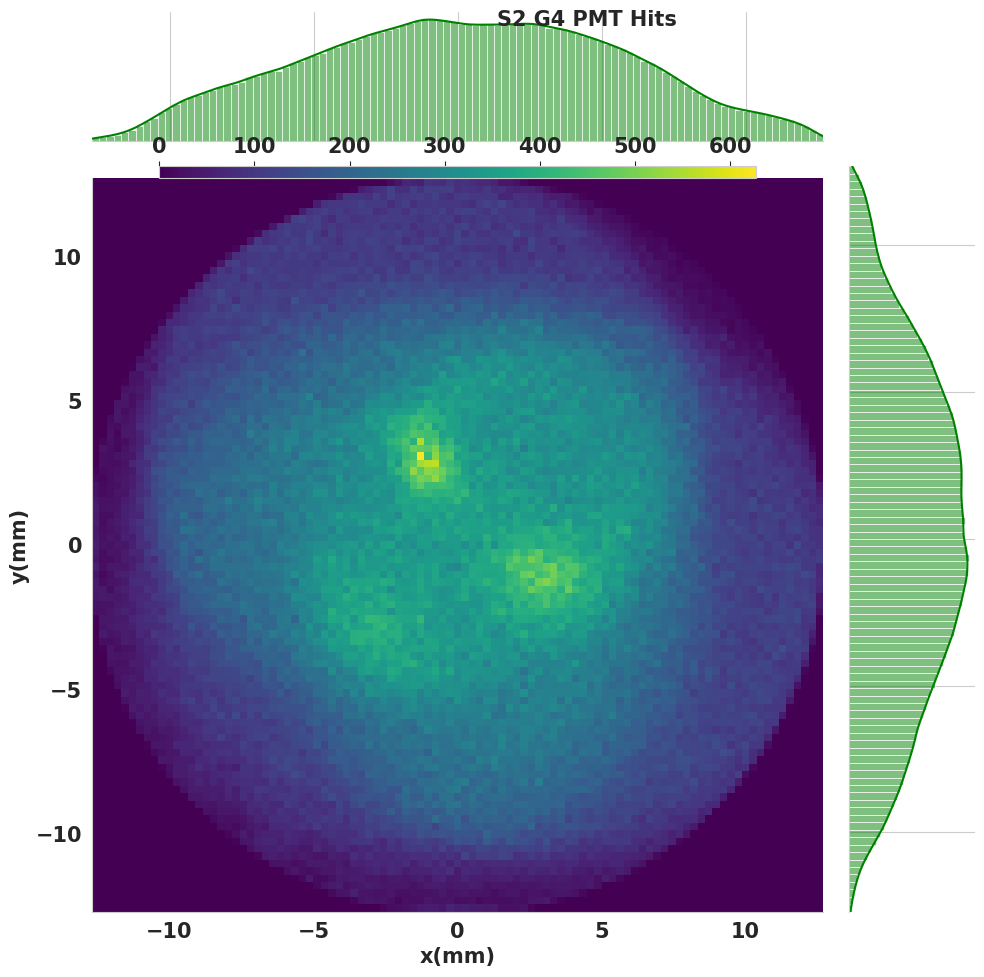

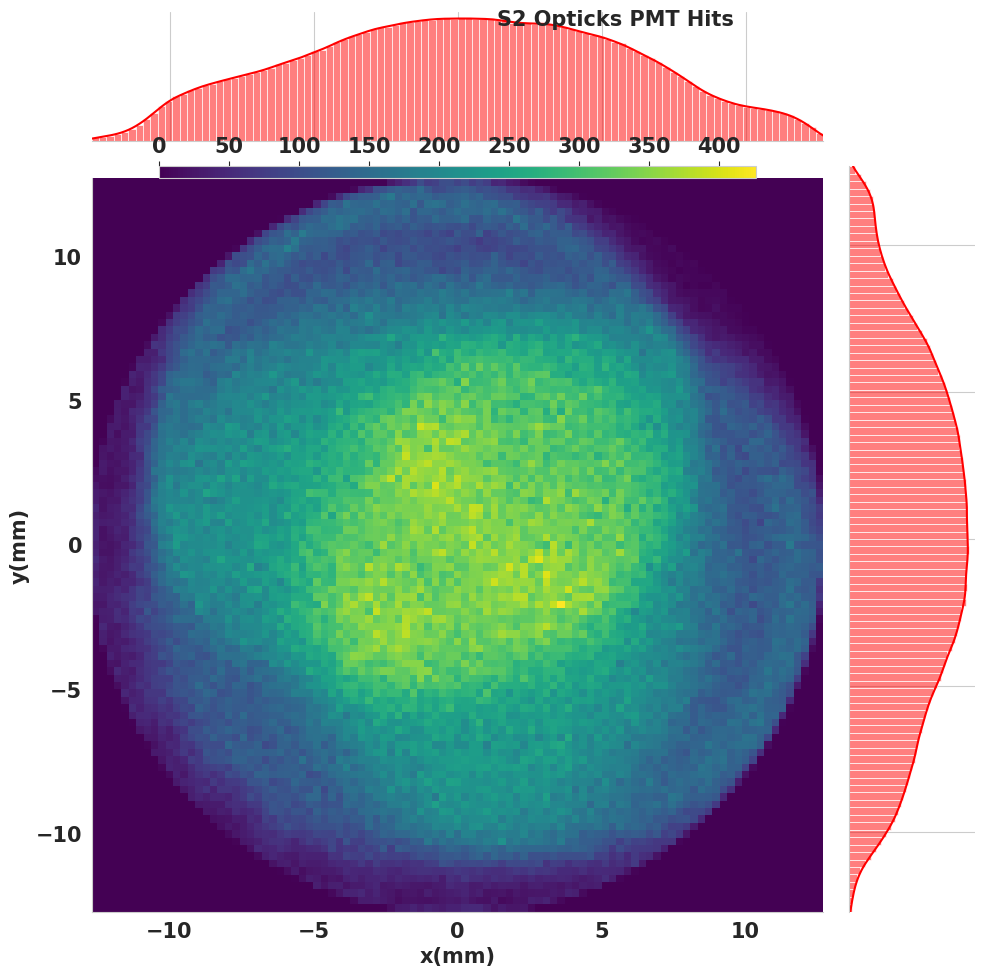

In [100]:
Binsize=100
G4X=G4Hits["x"][Geant4PMTMask]
G4Y=G4Hits["y"][Geant4PMTMask]
OX=OpticksHits['x'][OpticksPMTMask]
OY=OpticksHits['y'][OpticksPMTMask]
### Get S2 PMT Comparison
Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S2_Opticks_PMT_Hits","S2_G4_PMT_Hits"],["S2 Opticks PMT Hits","S2 G4 PMT Hits"],Binsize=Binsize)

<Figure size 4500x4500 with 0 Axes>

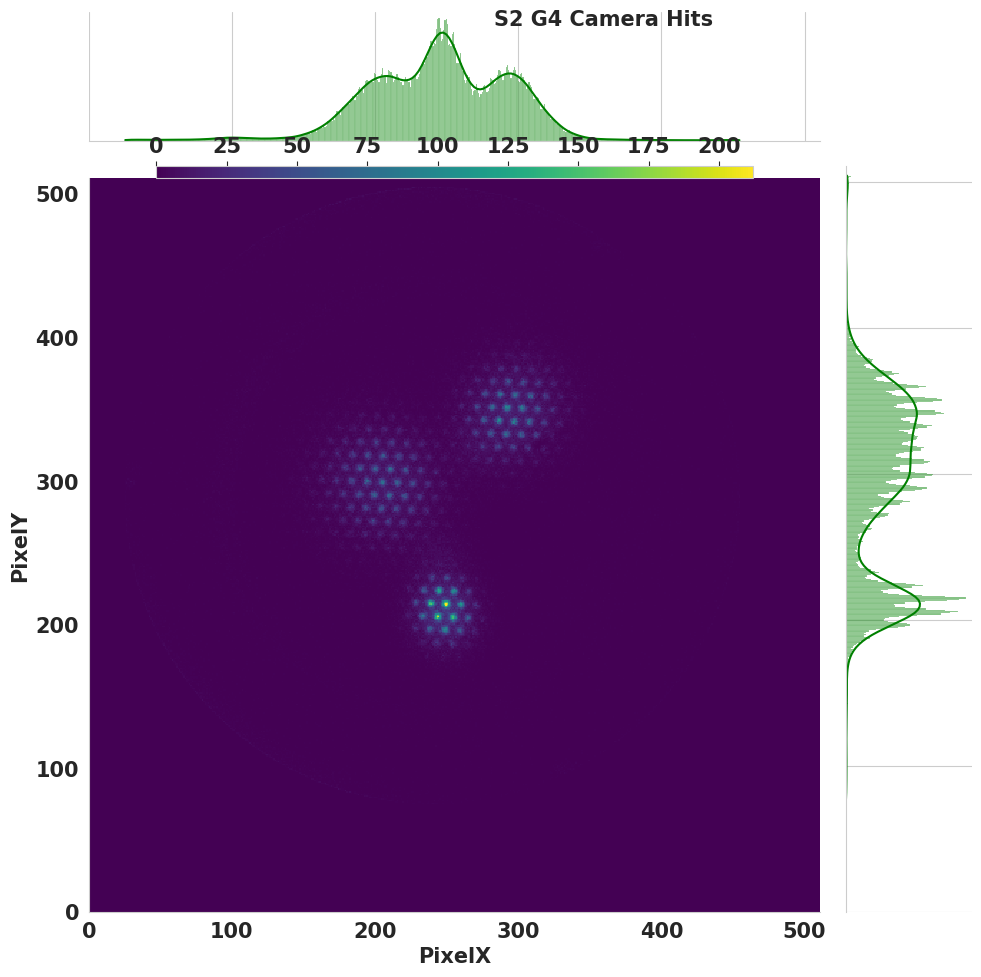

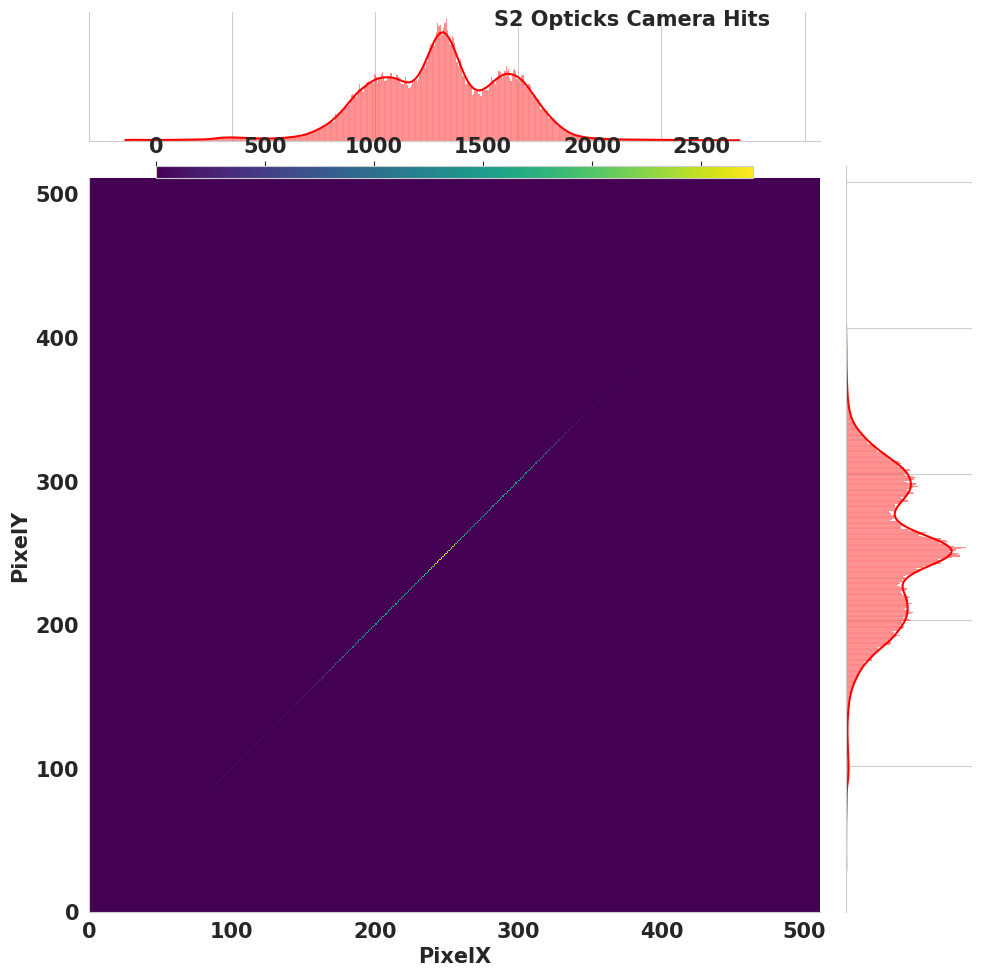

In [101]:

Binsize=512
G4X=G4Hits["x"][Geant4CamMask]
G4Y=G4Hits["y"][Geant4CamMask]
OX=OpticksHits['x'][OpticksCamMask]
OY=OpticksHits['y'][OpticksCamMask]

### Get S1 Camera Comparison
Plot2D_JointPlot([OX,OY],[G4X,G4Y],["S2_Opticks_Camera_Hits","S2_G4_Camera_Hits"],["S2 Opticks Camera Hits","S2 G4 Camera Hits"],isPlottext=false,isCameraView=True,labels=["PixelX","PixelY"],Binsize=Binsize)

In [102]:
import os
from PIL import Image,ImageFilter

def getHits(Hits,Mask):
    unique, counts = np.unique(Hits['event_id'][Mask], return_counts=True)
    return counts
def ListofFiles(path):
    filelist=[]
    for root, dirs, files in os.walk(path):
        for file in files:
             filelist.append(os.path.join(root,file))
    return filelist

 ## Average the images
def AvergImage(II,rangex,Single=True,start=0):
    img=np.zeros(II[0].shape)
    if (rangex>len(II.keys())):
        rangex=len(II.keys())
    # Average only one set
    if(Single):
        for i in range(start,rangex+start):
            img+=II[i]
        img=img/rangex
        return img
    else: # Average Multiple Sets of Images
        cnt=0
        fImages=[]
        while(cnt<=len(II.keys())-1):
            img+=II[cnt]
            if (cnt%(rangex)==0 and cnt>0):
                fImages.append(img/rangex)
                img=np.zeros(II[0].shape)
            cnt=cnt+1
        return fImages
    
def getImageValues(Files,EventLimit=1):
    if(type(Files) is list or type(Files) is np.ndarray):
        values={}
        count=0
        for file in Files:
            img1=Image.open(file)
            imgArray=np.array(img1)
            values[count]=imgArray
            count+=1
            if(EventLimit==count):
                break
        print(f" {count} frames in dictinary ")
    else:
        img1=Image.open(Files)
        values=np.array(img1)
    return values 

def Plot2D_JointPlot_Data(Data,BinSize,FileName,Title,isPlottext=False,vnorm=None,isCameraView=False,labels=["x(mm)","y(mm)"]):
    x=np.arange(0,BinSize,1)
    xx,yy=np.meshgrid(x,x)
    MeanPixel=np.min(Data.flatten())
    df_Data={labels[0]:xx.flatten(),labels[1]:yy.flatten(),"weights":(Data.flatten()-MeanPixel)/100}
  
    g=sns.jointplot(data=df_Data,x=labels[0], y=labels[1], weights=df_Data["weights"], kind='hist',bins=[x,x],marginal_kws={"bins":x,"kde":True,"weights":df_Data["weights"]},cmap="viridis",color="green",height=10,cbar=True,cbar_kws={"use_gridspec":False, "location":"top","aspect":50,"fraction":0.016,"pad":0,"aspect":50});
    #plt.hist2d(df_Data[labels[0]], df_Data[labels[1]],weights=df_Data["weights"], bins=[x,x], cmap="viridis");
    kde_x,kde_y=g.ax_joint.collections[0].get_paths()[0].vertices.T
    # print the KDE values
    print("KDE X values:",kde_x)
    print("KDE X values:",kde_y)

    
    if(isPlottext):
        x_mean = round(np.mean(df_Data[labels[0]]),2)
        x_std = round(np.std(df_Data[labels[0]]),2)
        g.ax_marg_x.axvspan(x_mean - x_std, x_mean + x_std, color='gray', alpha=0.35)

        y_mean = round(np.mean(df_Data[labels[1]]),2)
        y_std = round(np.std(df_Data[labels[1]]),2)
        g.ax_marg_y.axhspan(y_mean - y_std, y_mean + y_std, color='gray', alpha=0.35)
        g.refline(x=x_mean, y=y_mean, color='green', ls='--',alpha=0.4)
        ## Place the Values to Cells
        ax_marg_x = g.ax_marg_x
        Ydata= g.ax_marg_x.get_yticks()
        Xdata= g.ax_marg_y.get_yticks()
        ax_marg_y = g.ax_marg_y
        ## Place  the text to Marginal X axis
        print(x_mean,x_std)
        labelX_str=r'$\bar{X}$' + f" = {str(x_mean)}, " + r'$\sigma_{X}$'+f" = {str(x_std)}"
        labelY_str=r'$\bar{Y}$' + f" = {str(y_mean)}, \n " + r'$\sigma_{Y}$'+f" = {str(y_std)}"
        ## Mean and STD for X and Y
        ax_marg_x.text(x_mean + 2*x_std, np.mean(Ydata), labelX_str, fontsize=12)
        ax_marg_y.text( np.mean(Xdata),y_mean + 2*y_std, labelY_str, fontsize=12)
        
    plt.suptitle(Title,fontweight="bold",ha="left",size="medium")
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName[1]}.png")
            
    if (isSafeFiles):
        plt.savefig(f"{SavePath}/{FileName}.png")

In [103]:
PureXenon_8bar="/media/argon/Ilker_SSD/XenonRunNewII/8.08bar/S2/440Vpercm/1s/"
Data8bar=AvergImage(getImageValues(ListofFiles(PureXenon_8bar),-1),500,Single=True)


 600 frames in dictinary 


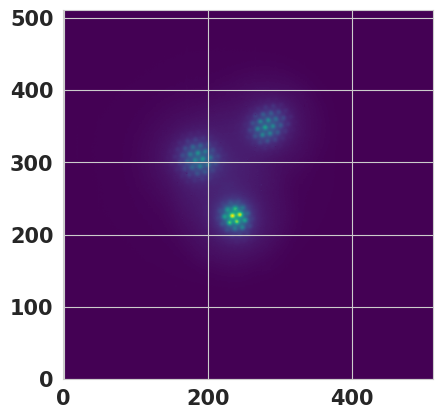

In [25]:
plt.imshow(Data8bar,cmap="viridis",origin='lower')


KDE X values: [0. 1. 1. 0. 0.]
KDE X values: [0. 0. 1. 1. 0.]


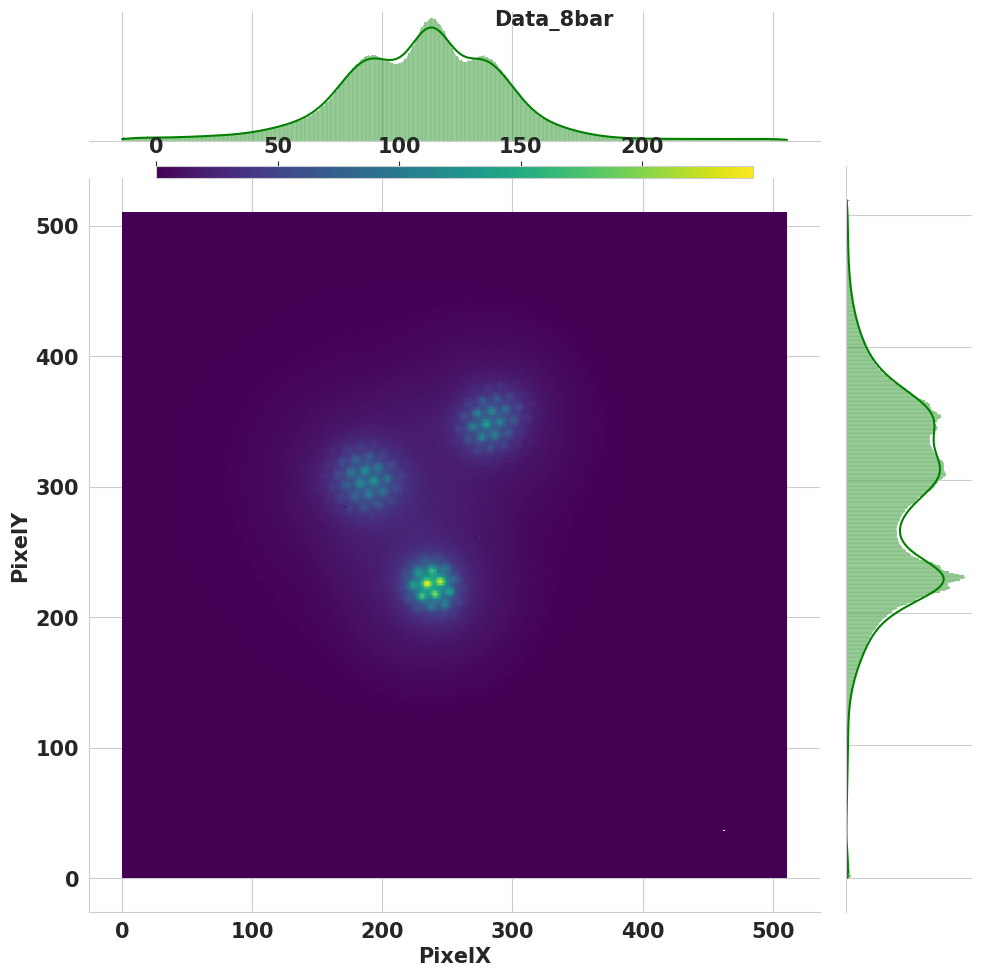

In [26]:

Plot2D_JointPlot_Data(Data8bar,512,"Data_8bar","Data_8bar",isPlottext=false,isCameraView=True,labels=["PixelX","PixelY"])

In [29]:
#_=plt.hist2d(Opticks["x"],Opticks["z"],bins=500)

In [105]:
G4X=G4Hits["x"][Geant4CamMask]
G4Y=G4Hits["y"][Geant4CamMask]
OX=OpticksHits['x'][OpticksCamMask]
OY=OpticksHits['y'][OpticksCamMask]
G4CamResponse=CamResponse([G4X,G4Y])
OpticksCamResponse=CamResponse([OX,OY])


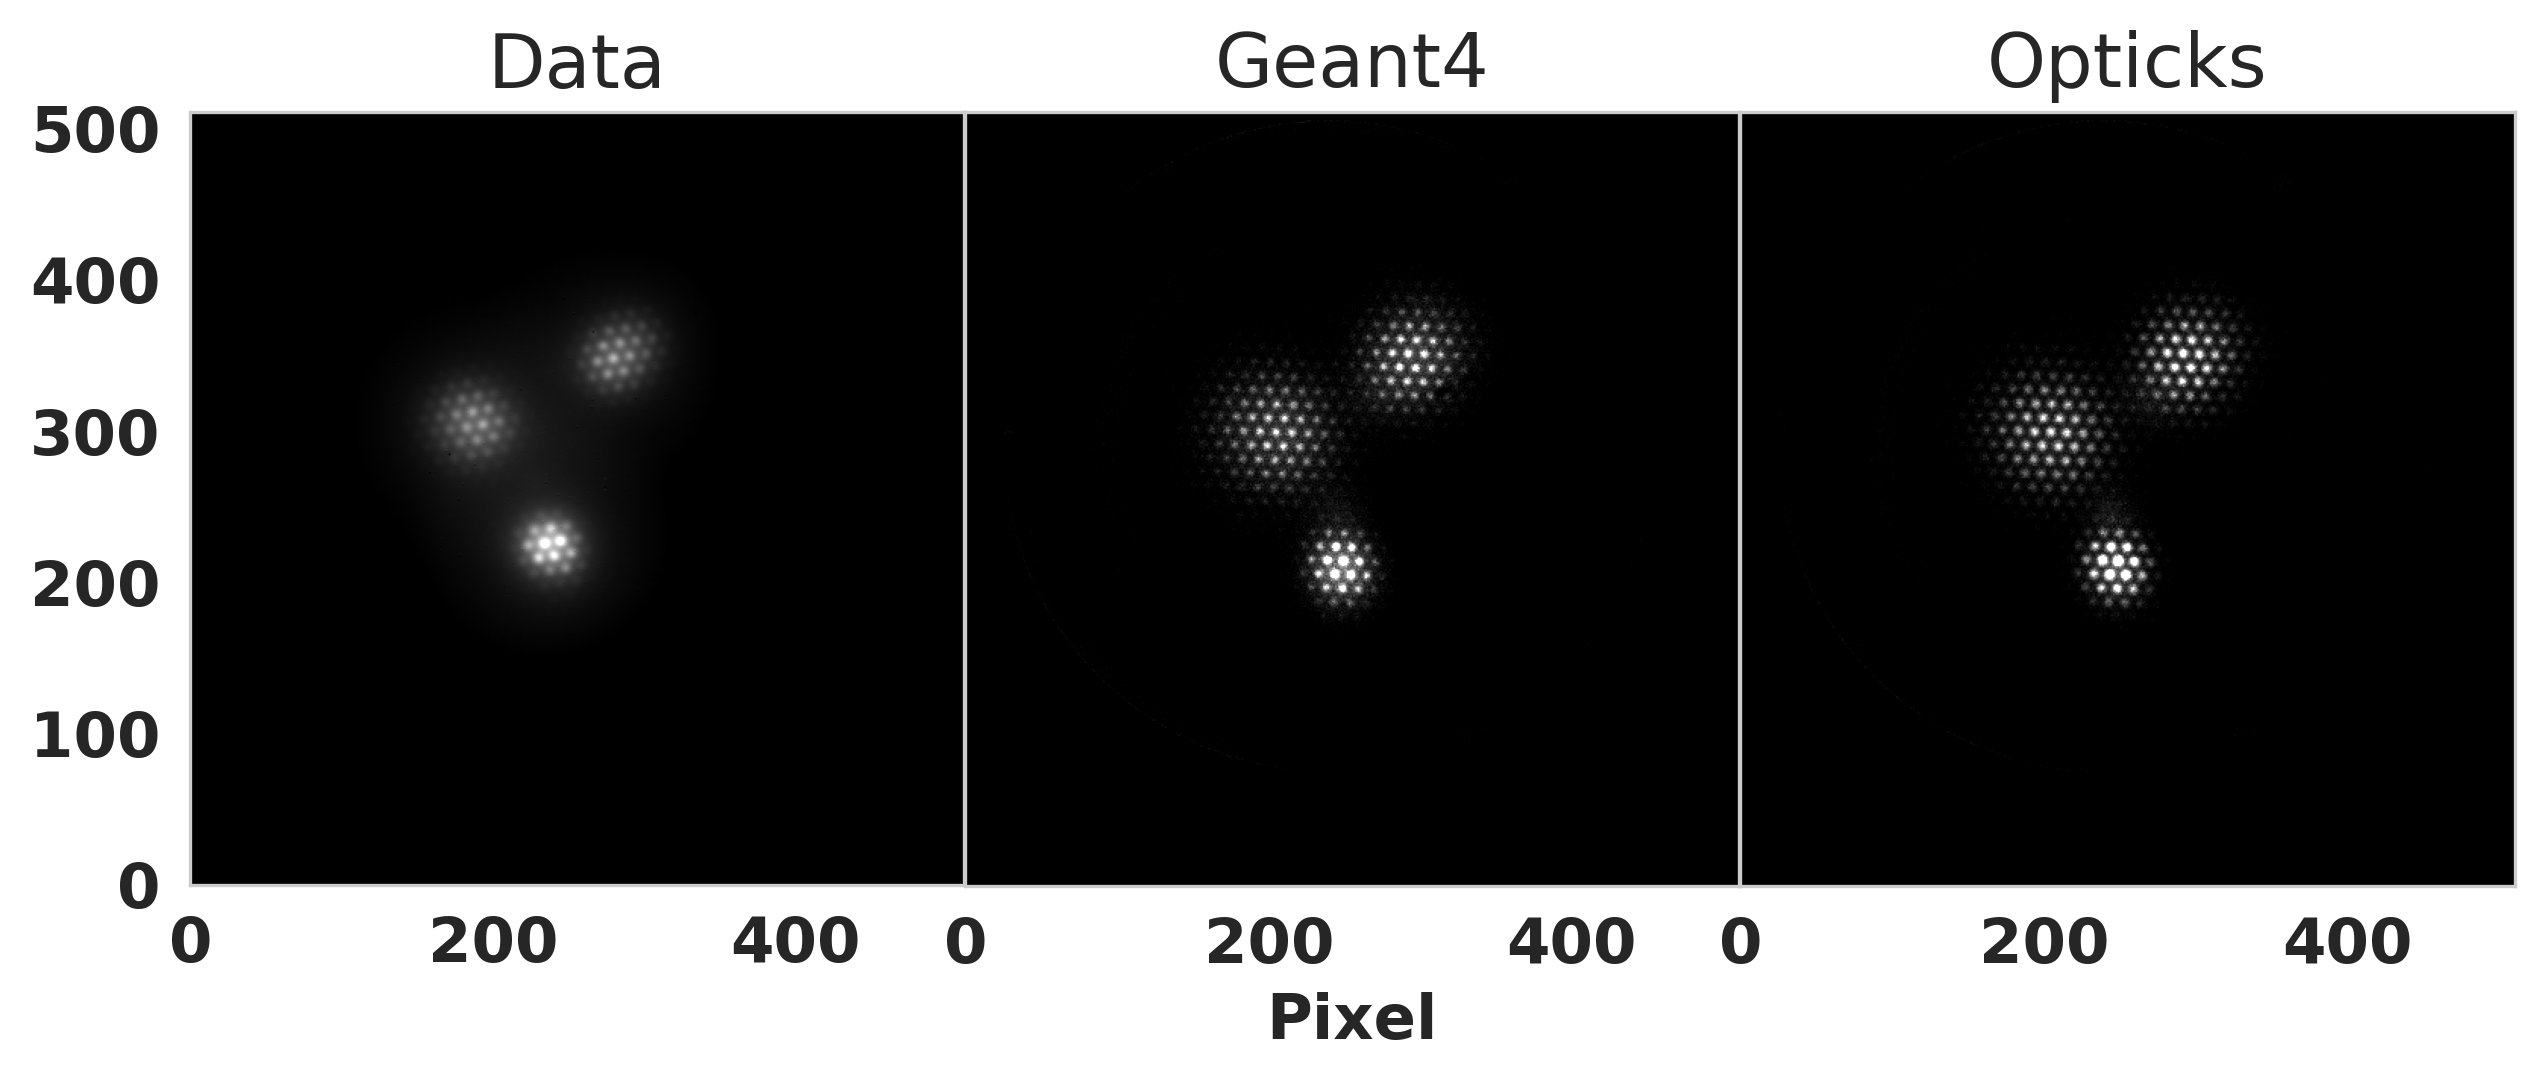

In [157]:
x=np.arange(0,512,1)

fig,ax=plt.subplots(1,3,figsize=(10,15),dpi=300,sharey=True)
ax[0].set_title("Data")
ax[0].imshow(Data8bar,origin='lower',cmap="gray",vmin=np.mean(Data8bar),vmax=np.max(Data8bar)*0.8)
ax[0].grid(visible=False)
ax[1].set_title("Geant4")
## Get Histogram
h=np.histogram2d(G4CamResponse["x"],G4CamResponse["y"],bins=[x,x])
## Apply Transformations 
G4Response=np.rot90(h[0],1)
G4Response=np.flip(G4Response,0)

ax[1].imshow(G4Response,cmap="gray", origin='lower',vmin=np.mean(G4Response),vmax=np.max(G4Response)*0.3)
ax[1].set_xlabel("Pixel")

ax[1].grid(visible=False)
#plt.tight_layout()
ax[2].set_title("Opticks")
## Get Histogram
h=np.histogram2d(OpticksCamResponse["x"],OpticksCamResponse["y"],bins=[x,x])
## Apply Transformations 
OpticksResponse=np.rot90(h[0],1)
OpticksResponse=np.flip(OpticksResponse,0)

ax[2].imshow(OpticksResponse,cmap="gray", origin='lower',vmin=np.mean(OpticksResponse),vmax=np.max(OpticksResponse)*0.3)
ax[2].grid(visible=False)
plt.subplots_adjust(wspace=0.001)


#fig.tight_layout()